In [69]:
%load_ext autoreload
%autoreload 2


from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from utils import *
from Instance import *
from Solution import *
from metaheuristic_approach import *

from copy import deepcopy
from time import time


##### MILP MODEL #####
import gurobipy as gp
from gurobipy import GRB

from first_model import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h

In [4]:
time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

In [5]:
seed = np.random.randint(1, 1000) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"seed : {seed}")
config_instance = {
    "seed": seed,

    "nb_jobs": 10,
    "nb_workers": 4,
    "nb_professions": 3,
    "proportion_tasks_per_profession": [0.2, 0.3, 0.3], # [profession 1, profession 2, profession 3]
    "max_nb_operations": 5,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.3, 0.5, 0.1], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.2, 0.5, 0.2, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": False
}

seed : 810


In [6]:
instance = Instance()
instance.from_config(config_instance)

set
[{0, 1, 2, 4, 6, 7, 11, 15, 17, 23, 24, 28, 32, 38, 42, 45, 46, 47, 53, 54}, {3, 5, 9, 10, 12, 14, 16, 18, 21, 22, 25, 26, 31, 33, 34, 37, 39, 40, 41, 43, 44, 48, 49, 50}, {35, 36, 8, 13, 19, 20, 51, 52, 27, 29, 30}]


In [7]:
# conversion des temps en int pour faciliter calcules et comparaisons
instance.tasks_times = np.array(instance.tasks_times, dtype=int)

In [8]:
print(instance)


 ===== Start of Instance: =====
Number of jobs: 10
Number of professions: 3
Number of tasks per profession: [11 16 16]
Max number of operations per Jobs: 5
Total number of tasks: 55
Total number of workers: 4
Task to profession mapping:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 51: 0, 52: 0, 53: 0, 54: 0}
Worker levels: shape=(4, 3)
 [[1.23319255 2.12807949 2.25827167]
 [2.92464721 2.06358283 2.25332117]
 [4.         2.92277357 3.50247374]
 [4.         1.58465849 2.08696472]]
Job difficulties: shape= (10,)
[3. 3. 2. 3. 3. 3. 3. 3. 3. 4.]
Job resale prices: shape= (10,)
[ 96.10009336  81.76746331  57.534035    64.18517362  54.37241566
  79.51488375 103.32040943  80.18138704  89.7340517

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


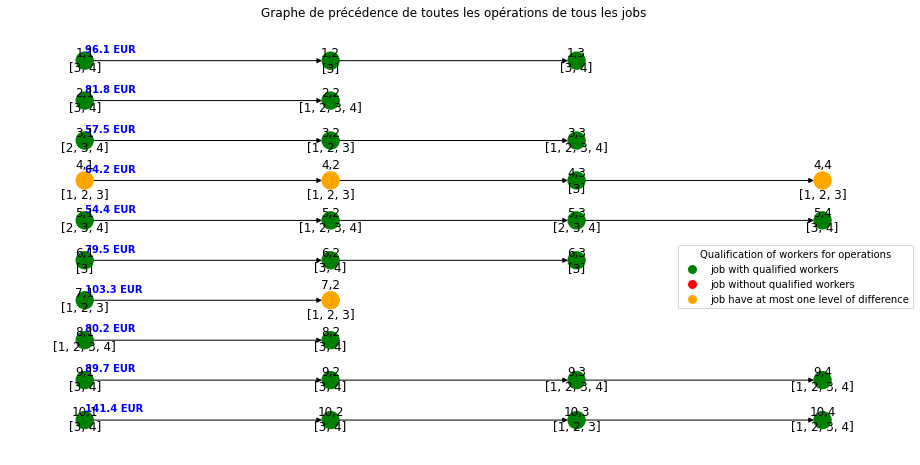

In [9]:
visualization_before_scheduling(instance, not_qualified=True)

In [11]:
TIME_LIMIT_MAKESPAN = instance.sum_of_job_alone() / 2
print("temps total laissé pour le scheduling :", TIME_LIMIT_MAKESPAN)
print("temps total nécessaire pour faire tous les jobs en travaillant seul :", instance.sum_of_job_alone())

constraints_config = {"constrained_makespan" : TIME_LIMIT_MAKESPAN, "job_with_no_skills" : False}

temps total laissé pour le scheduling : 90.5
temps total nécessaire pour faire tous les jobs en travaillant seul : 181


# Init chromosome

In [190]:
ga = GeneticAlgorithm(instance, constraints_config)
osc = ga.init_operations_order()
fwac = ga.init_first_worker_assignment(osc)
swac = ga.assign_second_workers_to_operations(fwac)

chromosome = Chrosomome(osc, fwac, swac)
print(chromosome)

osc :
[8 2 6 1 4 3 0 7 8 0 2 9 1 9 7 4 9 6 1 5 7 4 8 9 1 5 6 5 4 3 3 3]
fwac:
[-1  2  1  0  1  1  1  1  0  1  1  1  2  3  0  0  0  3  0  1  1  1 -1  0
 -1  0  1 -1  1  1  1  1]
swac:
[-1  3  3 -1  0 -1 -1 -1  2 -1  0 -1 -1  0  1  1  3 -1 -1  0 -1 -1 -1 -1
 -1 -1  3 -1 -1 -1 -1 -1]



# Décodage chromosome

In [191]:
decoder = Decoder(instance, ga)
s = decoder.decode_fast(chromosome)

makespan= 152.0
limit_makespan= 83.0
job_done= [0 1 1 1 1 1 1 0 0 1]
finish_time_job= [ 10.  44.  61.  80.  88.  99. 117. 103. 136. 152.]
job_done_before_limit= [1 1 1 1 0 0 0 0 0 0]


In [192]:
df = scheduling_to_df(s, instance)
check_df(df)

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


True

In [193]:
instance.levels_workers

array([[2.57785708, 3.38069556, 2.04125775],
       [3.99970983, 2.07837975, 4.        ],
       [1.1014021 , 2.52054469, 2.44856925],
       [2.18546951, 1.71888083, 2.21801089]])

# Generate multiple solutions

In [259]:
ga = GeneticAlgorithm(instance, constraints_config)
decoder = Decoder(instance, ga)


n = 5
chromosomes_list = []
objectives_list = []
solutions_list = []
for i in range(n):
    chromosome = ga.run()
    chromosomes_list.append(chromosome)
    objectives_list.append(decoder.decode_objectifs(chromosome))

In [260]:
df_objectives = pd.DataFrame(objectives_list, columns=['Objective 1', 'Objective 2', 'Objective 3'])
df_objectives

,Objective 1,Objective 2,Objective 3
0,125.525984,31.770777,19.506822
1,437.719521,33.270777,55.224959
2,125.525984,31.770777,24.994344
3,125.525984,31.770777,24.872161
4,262.616922,32.770777,38.263249


In [261]:
df_sol = []
for i in range(len(chromosomes_list)):
    df_sol.append(scheduling_to_df(decoder.decode(chromosomes_list[i]), instance))

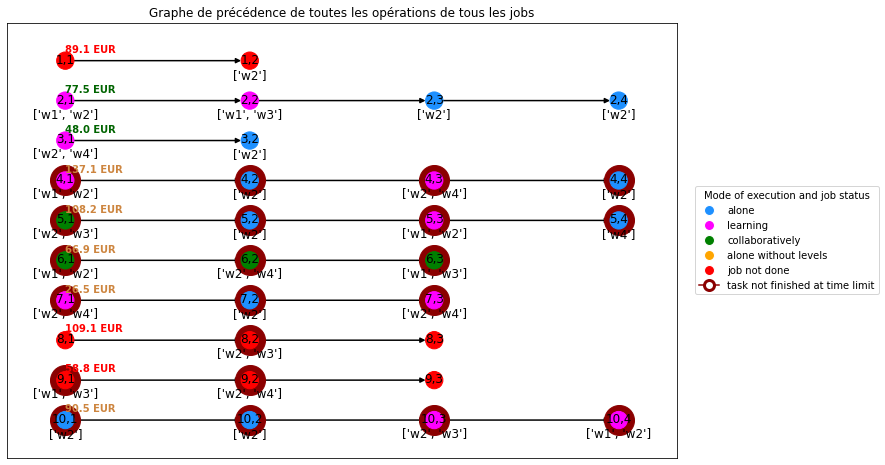

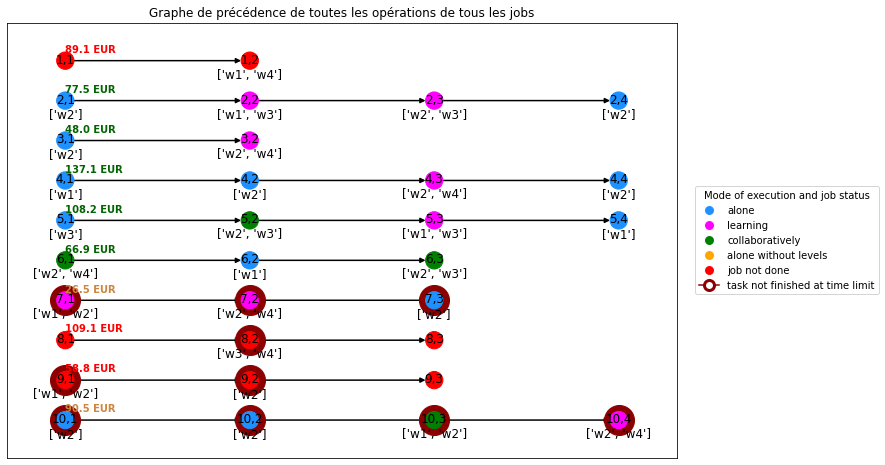

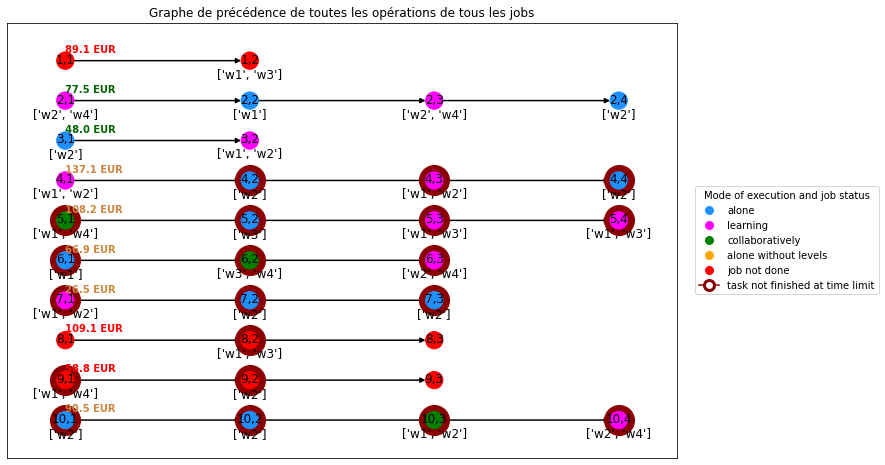

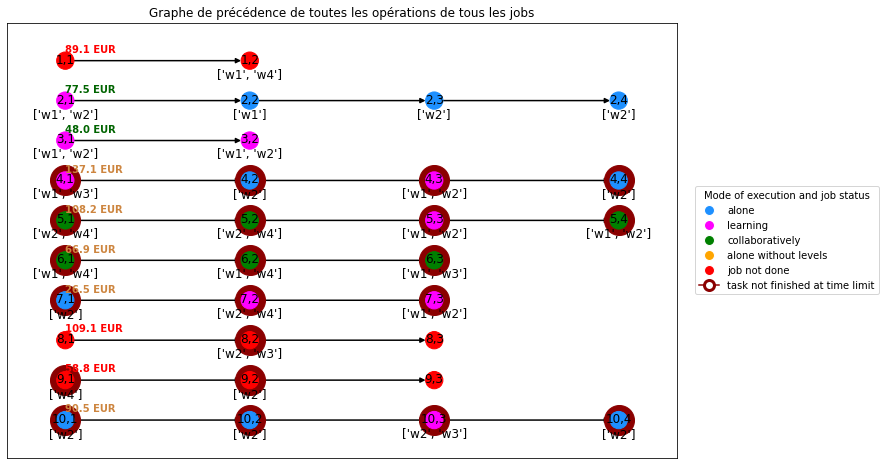

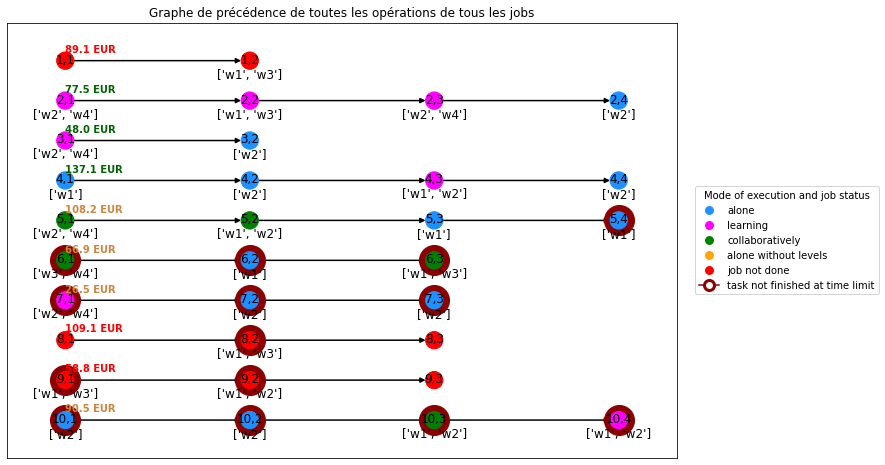

In [262]:
for i in range(len(chromosomes_list)):
    solutions_list.append(decoder.decode(chromosomes_list[i]))
    visualization_after_scheduling(instance, solutions_list[i], df_sol[i])

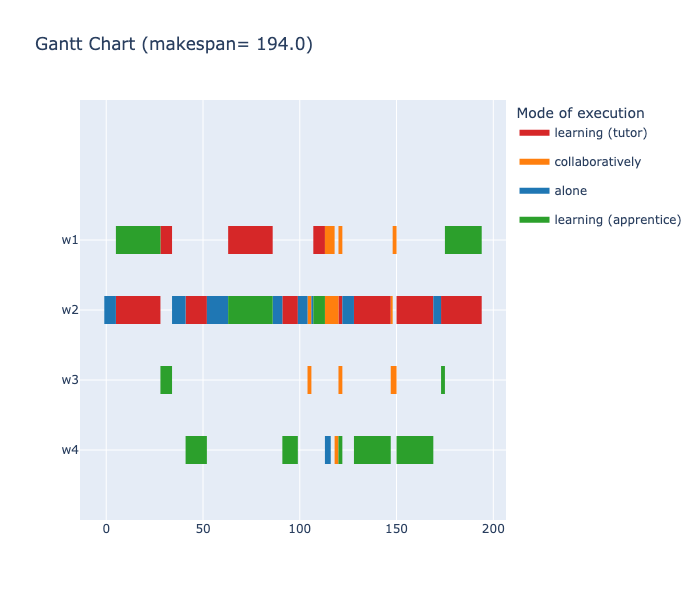

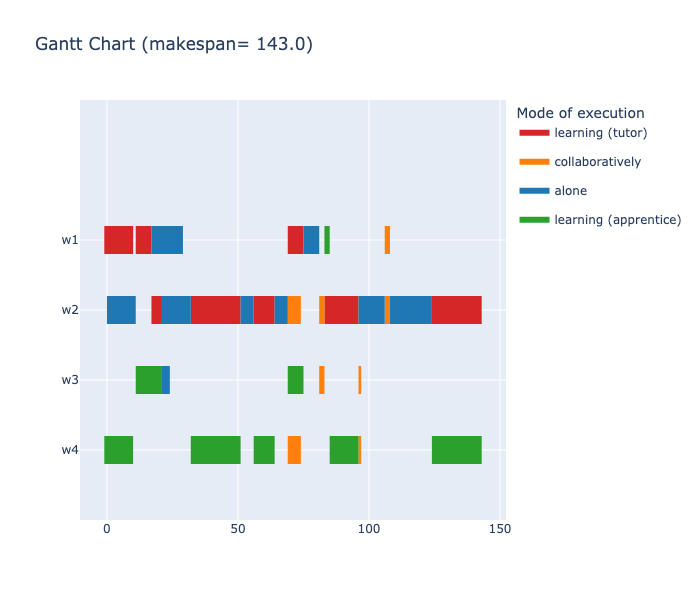

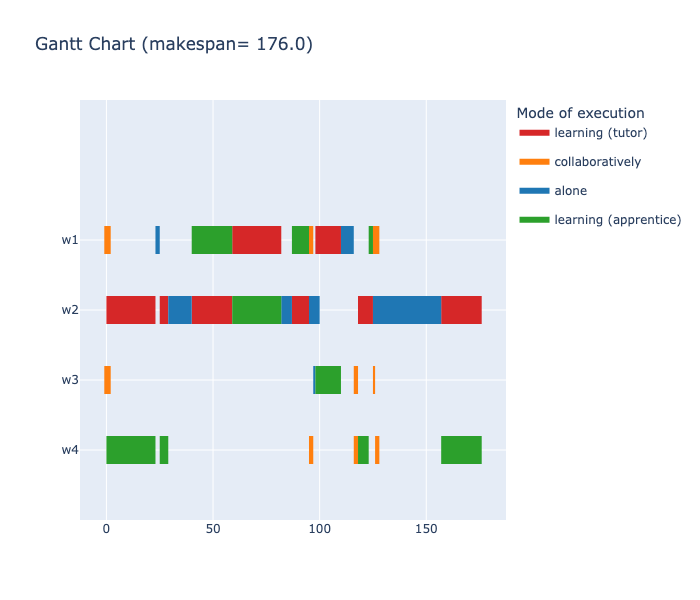

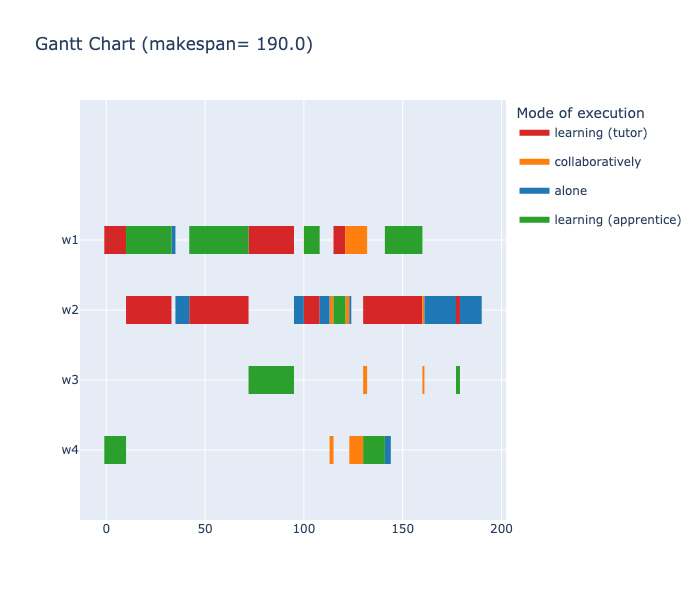

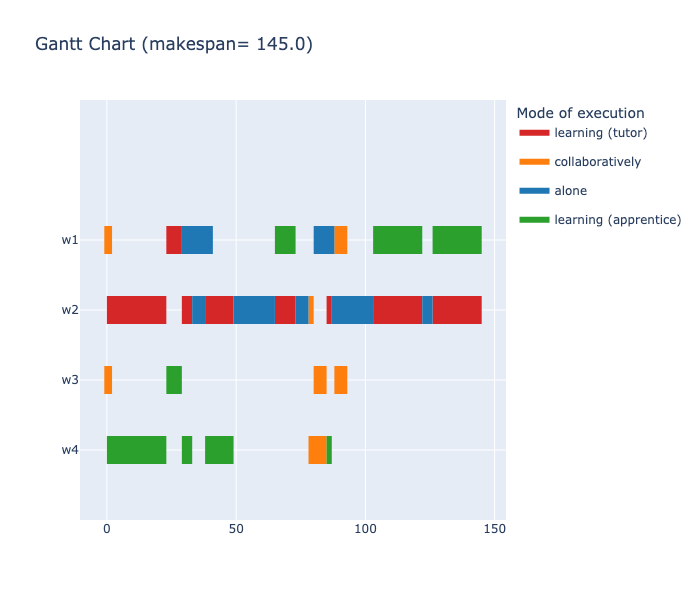

In [263]:
for i in range(len(chromosomes_list)):
    gantt_chart(df_sol[i], color=3, render="notebook")

In [122]:
w=3
print(len(start[w]))
for i in range(len(start[0])):
    print(f"[{start[w][i]}] - [{end[w][i]}]")

32
[0.0] - [14.0]
[14.0] - [16.0]
[16.0] - [22.0]
[-1.0] - [-1.0]
[26.0] - [32.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[32.0] - [33.0]
[-1.0] - [-1.0]
[59.0] - [62.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[77.0] - [93.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[118.0] - [121.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[142.0] - [147.0]
[-1.0] - [-1.0]
[-1.0] - [-1.0]
[150.0] - [154.0]
[-1.0] - [-1.0]
[175.0] - [180.0]
[-1.0] - [-1.0]
[185.0] - [191.0]


[0 5 9 1 1 3 4 3 7 6 8 8 4 3 0 7 9 5 2 4 5 2 1 3 0 9 8 8 1 7 4 6]
[-1  3  1  1  3  1  1  0  1  3  1  2  1  0  2  1  3  3 -1  0  0  2  3  1
 -1  2  1  2  1  3  2  0]
[-1  2  0 -1  2  2  2  1  2  2 -1  0 -1  1 -1  2  2  2 -1  2  3  3  1 -1
 -1 -1  2 -1 -1 -1  3 -1]
ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


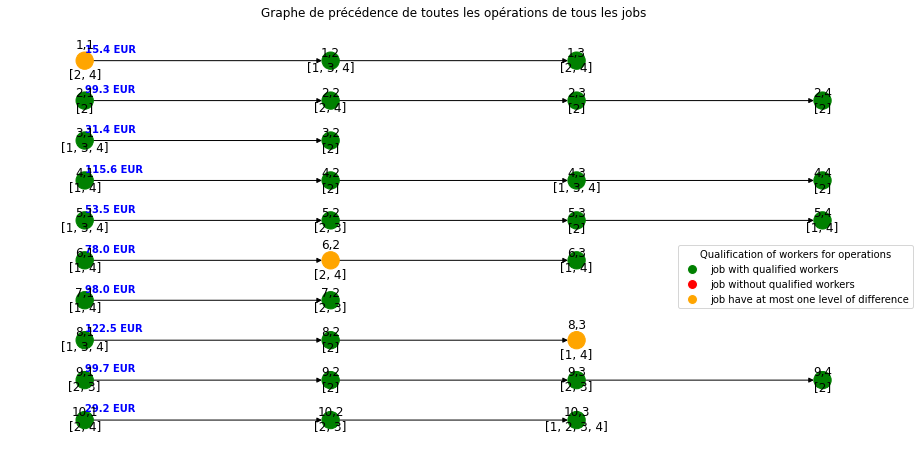

In [99]:
print(osc)
print(fwac)
print(swac)
visualization_before_scheduling(instance, not_qualified=True)

In [49]:
ga = GeneticAlgorithm(instance)
chromosome = ga.run()



decoder = Decoder(instance, ga)
decoder.constrained_start_date_calculate(chromosome)


# chromosome = meta.generate_random_chromosome()
# solution = decoder.decode(chromosome)
# # df = solution.to_df()

id_to_op= {0: (0, 0), 1: (0, 1), 2: (0, 2), 3: (1, 0), 4: (1, 1), 5: (2, 0), 6: (2, 1), 7: (2, 2), 8: (2, 3), 9: (3, 0), 10: (3, 1), 11: (3, 2), 12: (4, 0), 13: (4, 1), 14: (4, 2), 15: (5, 0), 16: (5, 1), 17: (5, 2), 18: (5, 3), 19: (6, 0), 20: (6, 1), 21: (6, 2), 22: (6, 3), 23: (7, 0), 24: (7, 1), 25: (7, 2), 26: (7, 3), 27: (8, 0), 28: (8, 1), 29: (9, 0), 30: (9, 1), 31: (9, 2)}
op_to_id= {(0, 0): 0, (0, 1): 1, (0, 2): 2, (1, 0): 3, (1, 1): 4, (2, 0): 5, (2, 1): 6, (2, 2): 7, (2, 3): 8, (3, 0): 9, (3, 1): 10, (3, 2): 11, (4, 0): 12, (4, 1): 13, (4, 2): 14, (5, 0): 15, (5, 1): 16, (5, 2): 17, (5, 3): 18, (6, 0): 19, (6, 1): 20, (6, 2): 21, (6, 3): 22, (7, 0): 23, (7, 1): 24, (7, 2): 25, (7, 3): 26, (8, 0): 27, (8, 1): 28, (9, 0): 29, (9, 1): 30, (9, 2): 31}


[[],
 [],
 [],
 [],
 [29],
 [],
 [],
 [3],
 [0],
 [1],
 [],
 [30],
 [],
 [19],
 [20],
 [9],
 [],
 [12],
 [23],
 [],
 [13],
 [24],
 [27],
 [21],
 [10],
 [15],
 [5],
 [16],
 [25],
 [6],
 [17],
 [7]]

In [50]:
a = decoder.count_nb_tasks_done_by_worker(chromosome.worker_assignment, chromosome.second_worker_assignment)

In [52]:
for w,count in zip(a[0], a[1]):
    print(f"worker {w} : {count} tasks")

worker 0 : 4 tasks
worker 1 : 23 tasks
worker 2 : 3 tasks
worker 3 : 21 tasks


In [58]:
s, f = decoder.start_date_calculate(chromosome)

In [ ]:
idx_op = np.where(s[1, :] >= 0)
print(s[1, idx_op])
print(f[1, idx_op])


[[ 23.  30.   0.   5.  94. 156. 178.  41.  61. 141.  30.  69.  99. 141.
  166.  45.  53. 134.  18. 119. 119.   0.  30.]]
[[ 30.  41.   5.   7.  99. 163. 182.  45.  69. 143.  36.  94. 119. 156.
  170.  53.  61. 141.  23. 123. 134.  18.  38.]]


In [ ]:
index_sorted = np.argsort(s[1, idx_op])
print(sorted)
# for x in zip(s[1, idx_op], f[1, idx_op]):
#     print(x, y)

[[ 2 21  3 18  0 10 22  1  7 15 16  8 11  4 12 19 20 17  9 13  5 14  6]]


In [11]:
TIME_LIMIT_MAKESPAN = instance.sum_of_job_alone() / 2
print("temps total laissé pour le scheduling :", TIME_LIMIT_MAKESPAN)
print("temps total nécessaire pour faire tous les jobs en travaillant seul :", instance.sum_of_job_alone())

constraints_config = {"constrained_makespan" : TIME_LIMIT_MAKESPAN, "job_with_no_skills" : False}

temps total laissé pour le scheduling : 76.5
temps total nécessaire pour faire tous les jobs en travaillant seul : 153


---

# Random Search

In [12]:
# RANDOM SEARCH

encoding_dicos = Encoding_Dicos(instance)

generator = ChromosomeGenerator(instance, encoding_dicos, constraints_config)

decoder = Decoder(instance, encoding_dicos, constraints_config)

weights = {
    "profit" : 100,
    "skills" : 10,
    "cognitive_load" : 1
}

evaluator = Evaluator(decoder, weights)


random_search = RandomSearch(generator, evaluator)
MAX_ITER = 1000
all_viewed_list_RS, best_list_RS, i_find_best_list_RS = random_search.run(MAX_ITER, verbose=True)

iter 0: New best fitness: 24926.34435377712
iter 2: New best fitness: 38819.22997150803
iter 3: New best fitness: 44638.95796679014
iter 18: New best fitness: 47094.83675146798
iter 24: New best fitness: 47258.039742366986
iter 30: New best fitness: 67132.58842723415
iter 81: New best fitness: 68791.15992596313


In [13]:
print("nombre de mise à jour du meilleur résultat :", len(best_list_RS))
best = best_list_RS[-1]

nombre de mise à jour du meilleur résultat : 7


### Graphique de l'évolution de la fitness des solutions trouvées au cours des itérations

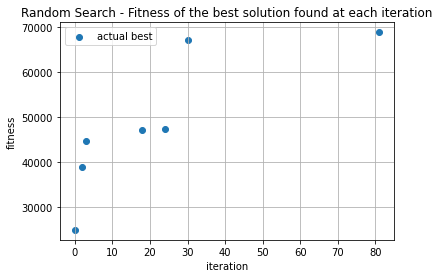

In [14]:
y1 = [x.fitness for x in best_list_RS] # actual best found

x = np.arange(len(all_viewed_list_RS))
y2 = [x.fitness for x in all_viewed_list_RS] # all viewed

plt.scatter(i_find_best_list_RS, y1, label="actual best")
# plt.plot(x, y2, color="orange", label="evolution")
plt.xlabel("iteration")
plt.ylabel("fitness")
plt.title("Random Search - Fitness of the best solution found at each iteration")
plt.legend()
plt.grid()
plt.show()

### Visualisation de la meilleure solution trouvée

In [15]:
best_RS = best_list_RS[-1]
print("Meilleure solution trouvée par la recherche locale :")
print(best_RS) 

Meilleure solution trouvée par la recherche locale :
osc :
[0 8 2 8 4 1 7 4 9 1 4 8 5 2 8 9 6 3 5 9 4 2 0 9 6 0 5 3 7 3 3]
fwac:
[ 3  2  3  3  3  3  0  0 -1 -1 -1 -1  2  2  1  3  2  2  2 -1 -1  0  2  2
  3  2  0  2  3  2  1]
swac:
[ 1  3  2  1 -1 -1  1 -1 -1 -1 -1 -1  0  1  0  1 -1 -1  1 -1 -1  3  1 -1
  1  0  1  1 -1 -1 -1]
fitness: 68791.15992596313
objectives: (688.4414383619992, 2.5, 77.9839102367801)



In [16]:
s = decoder.decode_solution(best_RS.osc, best_RS.fwac, best_RS.swac)

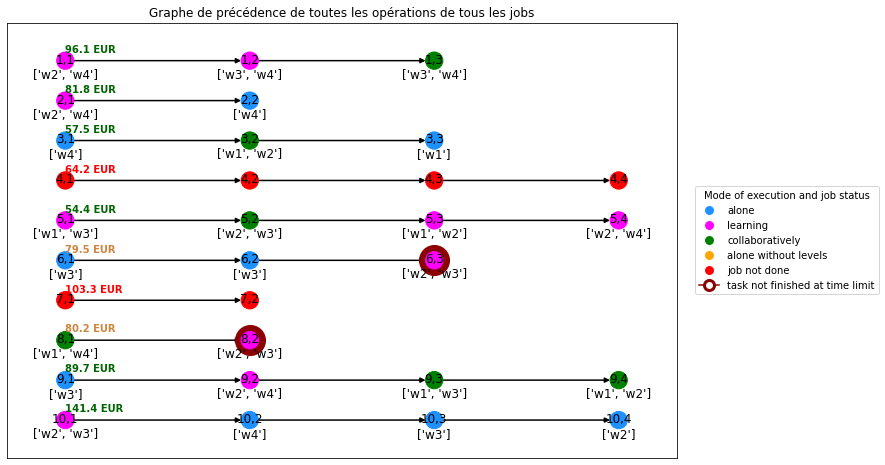

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


True

In [17]:
df = scheduling_to_df(s, instance)
visualization_after_scheduling(instance, s, df)
check_df(df)

### Diagramme de Gantt de la meilleure solution trouvée

##### Selon les opérations

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(10,1)': '#AB63FA', '(10,2)': '#FFA15A', '(10,3)': '#19D3F3', '(10,4)': '#FF6692', '(2,1)': '#B6E880', '(2,2)': '#FF97FF', '(3,1)': '#FECB52', '(3,2)': '#1F77B4', '(3,3)': '#FF7F0E', '(5,1)': '#2CA02C', '(5,2)': '#D62728', '(5,3)': '#9467BD', '(5,4)': '#8C564B', '(6,1)': '#E377C2', '(6,2)': '#7F7F7F', '(6,3)': '#BCBD22', '(8,1)': '#17BECF', '(8,2)': 'rgb(141,211,199)', '(9,1)': 'rgb(255,255,179)', '(9,2)': 'rgb(190,186,218)', '(9,3)': 'rgb(251,128,114)', '(9,4)': 'rgb(128,177,211)'}


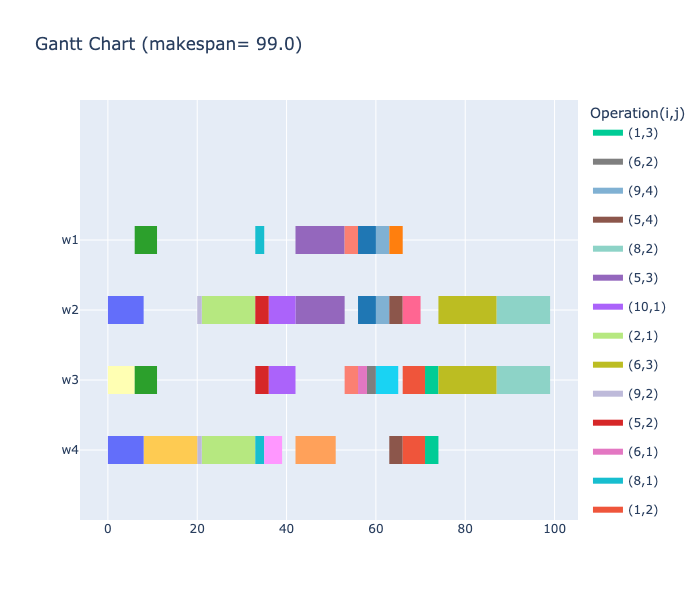

In [18]:
gantt_chart(df, color=0, render="notebook")

##### Selon les opérations faites avant ou après limite de temps donnée

 limite de temps :  76.5


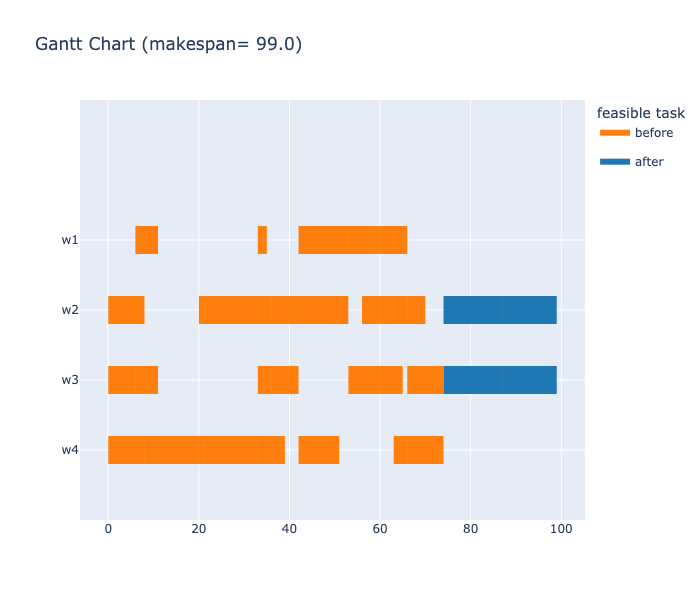

In [20]:
print(" limite de temps : " ,TIME_LIMIT_MAKESPAN)
gantt_chart(df, color=1, render="notebook", separate_little=True)

#### Selon les jobs

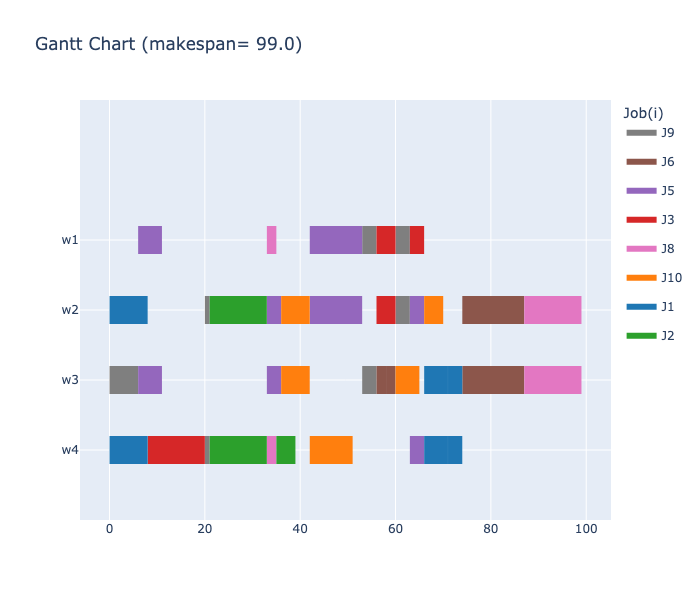

In [21]:
gantt_chart(df, color=2, render="notebook")

##### Selon les modes

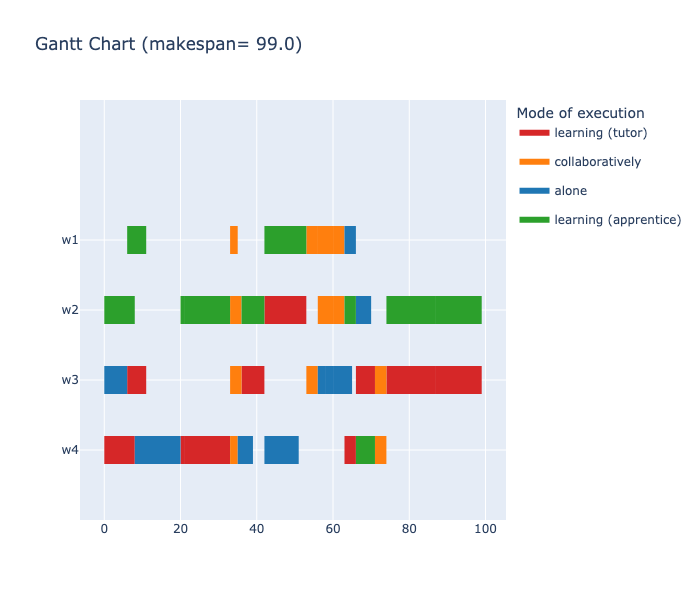

In [22]:
gantt_chart(df, color=3, render="notebook")

#### Selon les jobs done before ou after limite de temps donnée

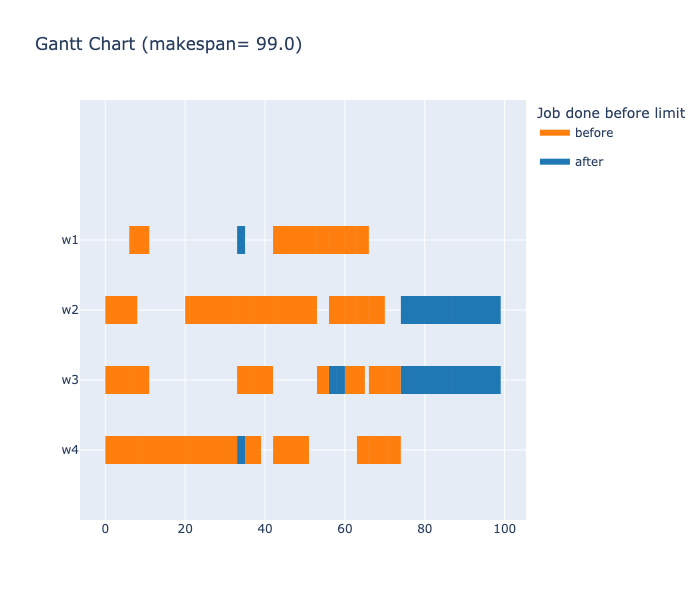

In [23]:
gantt_chart(df, color=4, render="notebook")

##### DataFrame de la meilleure solution trouvée

In [25]:
df
check_df(df)

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


True

---

# Local Search

In [26]:
encoding_dicos = Encoding_Dicos(instance)

generator = ChromosomeGenerator(instance, encoding_dicos, constraints_config)

decoder = Decoder(instance, encoding_dicos, constraints_config)

weights = {
    "profit" : 100,
    "skills" : 10,
    "cognitive_load" : 1
}

evaluator = Evaluator(decoder, weights)

neighborhood_SWAP_OP = SwapOperationNeighborhood(n=10)
neighborhood_MOVE_OP = MoveOneOperationNeighborhood()
neighborhood_SWAP_FIXED = SwapFixedOperationsNeighborhood(k=10, n=10)

selector = SoftmaxSelector()

MAX_ITER = 1000

In [27]:
local_search_swap_op = LocalSearch(
    generator, 
    evaluator,
    neighborhood_SWAP_OP,
    selector
)

local_search_move_op = LocalSearch(
    generator, 
    evaluator,
    neighborhood_MOVE_OP,
    selector
)

local_search_swap_fixed = LocalSearch(
    generator, 
    evaluator,
    neighborhood_SWAP_FIXED,
    selector
)

local_search_family = [local_search_swap_op, local_search_move_op, local_search_swap_fixed]

In [30]:
solution_list = []
time_list = []
for i in range(len(local_search_family)):
    time_start = time.time()
    solution_list.append(local_search_family[i].run(MAX_ITER, verbose=True))
    time_list.append(time.time() - time_start)
    

Initial fitness: 36622.66361480017
iter 1: New best fitness: 48016.166279363424
iter 2: New best fitness: 55958.49726108905
iter 3: New best fitness: 61694.61367238393
iter 5: New best fitness: 61758.665748713756
iter 6: New best fitness: 69700.9967304394
iter 193: New best fitness: 75129.29837538648
Initial fitness: 26357.765707613486
iter 1: New best fitness: 31786.092328220708
iter 2: New best fitness: 40121.34473007613
iter 4: New best fitness: 43325.665885690054
iter 5: New best fitness: 57462.086192548755
iter 8: New best fitness: 65632.87224150321
iter 14: New best fitness: 73574.57602616136
iter 92: New best fitness: 78997.90264676859
iter 103: New best fitness: 79320.97662649686
Initial fitness: 24761.808277716053
iter 1: New best fitness: 53202.96813956096
iter 2: New best fitness: 53431.15307606284
iter 10: New best fitness: 57376.644961341735
iter 13: New best fitness: 57604.82989784361
iter 34: New best fitness: 63347.58171208056
iter 39: New best fitness: 65547.4310102961

In [31]:
time_list

[13.32351803779602, 35.89985799789429, 12.812013864517212]

In [32]:
y = [ [] for _ in range(len(solution_list)) ]

for i in range(len(solution_list)):
    for j in range(len(solution_list[i][0])):
        y[i].append(solution_list[i][0][j].fitness)
print(len(y), len(y[0]), len(y[1]), len(y[2]))

3 1000 1000 1000


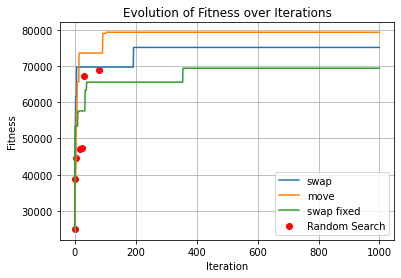

In [33]:
x = np.arange(len(solution_list[0][0]))

x_RS = i_find_best_list_RS
y_RS = [chromosome.fitness for chromosome in best_list_RS]


plt.plot(x, y[0], label='swap')
plt.plot(x, y[1], label='move')
plt.plot(x, y[2], label='swap fixed')

plt.scatter(x_RS, y_RS, color='red', label='Random Search')


plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('Evolution of Fitness over Iterations')
plt.legend()
plt.grid()
plt.show()

In [34]:
best = solution_list[0][1][-1]
print(best)

osc :
[3 4 9 1 7 5 9 3 9 8 4 8 1 2 8 7 6 8 6 3 2 9 5 4 5 2 4 0 0 3 0]
fwac:
[ 2  2  3  2  0  2  2  3 -1 -1 -1 -1  3  2  1  3  2  3  2 -1 -1  1  2  3
  2  3  1  3  2  0  1]
swac:
[ 1  0  1  1 -1  3  0  1 -1 -1 -1 -1  0 -1  0  1  3  2  3 -1 -1  2  1  1
  1  0  3 -1 -1 -1  0]
fitness: 75129.29837538648
objectives: (752.037615794346, 3.0, 104.46320404812283)



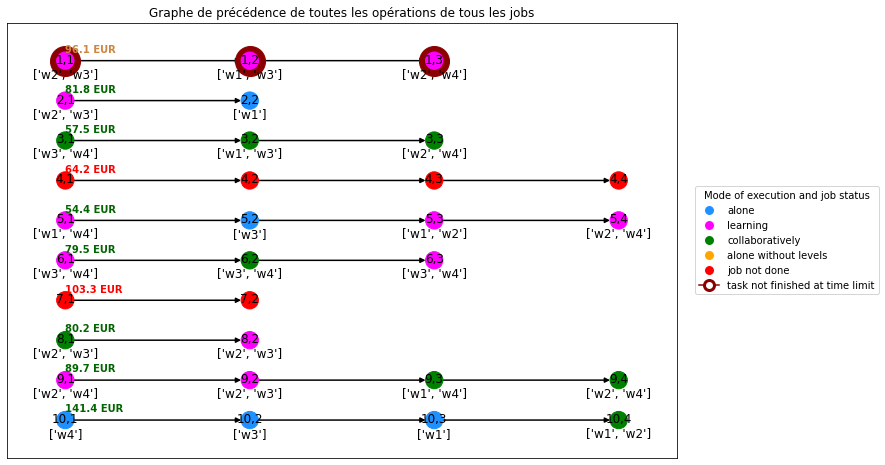

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


True

In [35]:
s = decoder.decode_solution(best.osc, best.fwac, best.swac)
df = scheduling_to_df(s, instance)
visualization_after_scheduling(instance, s, df)
check_df(df)

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(1,4)': '#AB63FA', '(10,1)': '#FFA15A', '(10,2)': '#19D3F3', '(10,3)': '#FF6692', '(3,1)': '#B6E880', '(3,2)': '#FF97FF', '(3,3)': '#FECB52', '(3,4)': '#1F77B4', '(4,1)': '#FF7F0E', '(4,2)': '#2CA02C', '(4,3)': '#D62728', '(4,4)': '#9467BD', '(5,1)': '#8C564B', '(5,2)': '#E377C2', '(6,1)': '#7F7F7F', '(6,2)': '#BCBD22', '(6,3)': '#17BECF', '(6,4)': 'rgb(141,211,199)', '(7,1)': 'rgb(255,255,179)', '(7,2)': 'rgb(190,186,218)'}


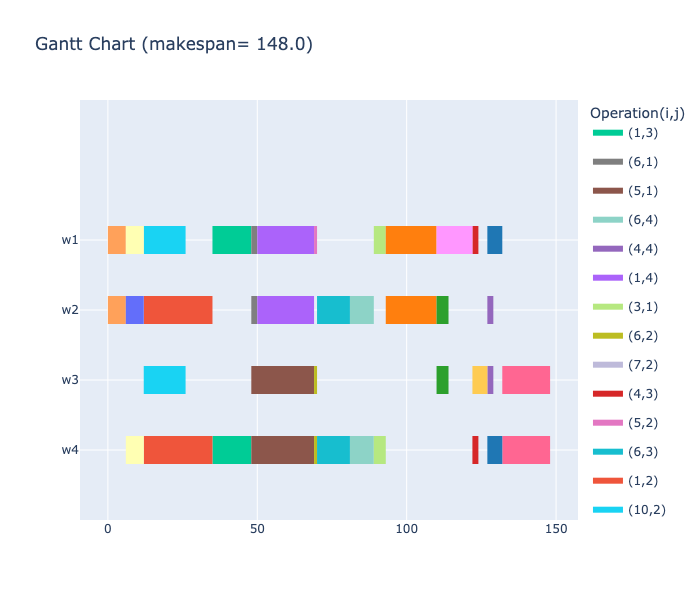

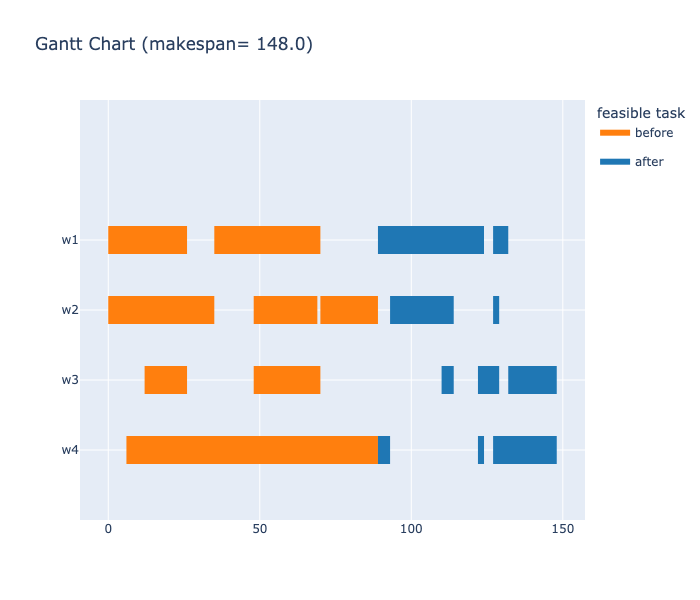

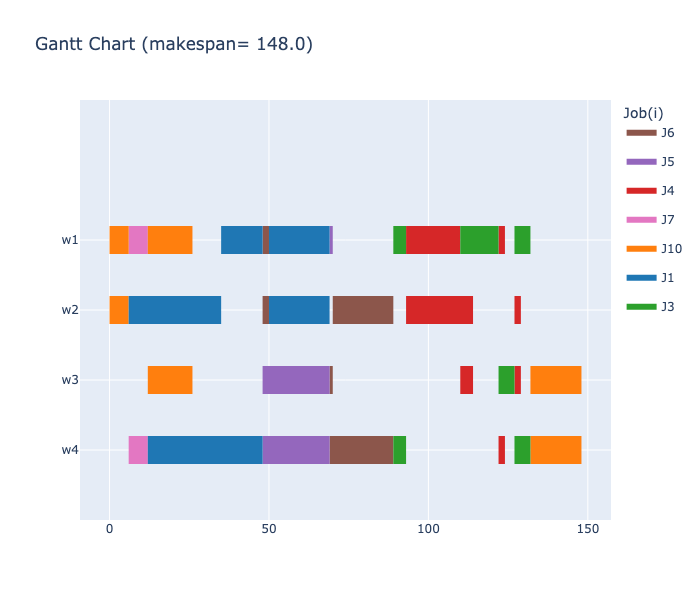

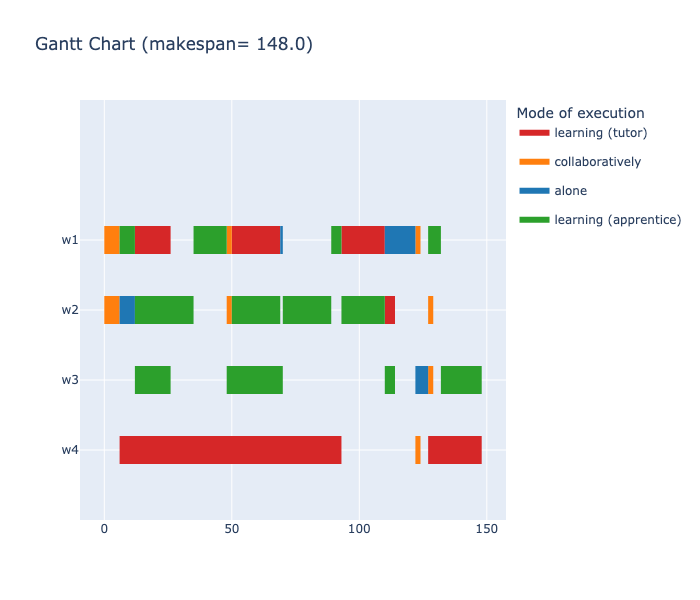

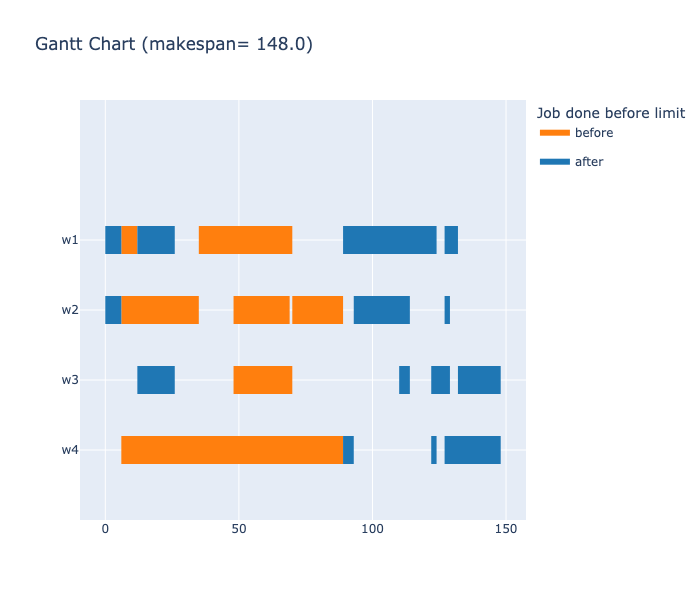

In [441]:
gantt_chart(df, color=0, render="notebook")
gantt_chart(df, color=1, render="notebook")
gantt_chart(df, color=2, render="notebook")
gantt_chart(df, color=3, render="notebook")
gantt_chart(df, color=4, render="notebook")

In [442]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,6.0,6.0,6.0,"(10,1)",J10,collaboratively,2.104999,2.0,0,before,after,10.0,0.0
1,w1,6.0,12.0,12.0,6.0,"(7,1)",J7,learning (apprentice),2.027763,3.0,0,before,before,31.0,2.0
2,w1,12.0,26.0,26.0,14.0,"(10,2)",J10,learning (tutor),2.104999,2.0,0,before,after,46.0,0.0
3,w1,35.0,48.0,48.0,13.0,"(1,3)",J1,learning (apprentice),2.104999,3.0,0,before,before,44.0,0.0
4,w1,48.0,50.0,50.0,2.0,"(6,1)",J6,collaboratively,2.104999,2.0,0,before,before,9.0,0.0
5,w1,50.0,69.0,69.0,19.0,"(1,4)",J1,learning (tutor),4.000000,3.0,0,before,before,24.0,1.0
6,w1,69.0,70.0,70.0,1.0,"(5,2)",J5,alone,2.104999,2.0,0,before,before,2.0,0.0
7,w1,70.0,70.0,70.0,0.0,"(7,2)",J7,collaboratively,2.104999,2.0,0,before,before,2.0,0.0
8,w1,89.0,93.0,93.0,4.0,"(3,1)",J3,learning (apprentice),2.104999,3.0,2.5,after,after,47.0,0.0
9,w1,93.0,110.0,110.0,17.0,"(4,1)",J4,learning (tutor),4.000000,3.0,19.5,after,after,18.0,1.0


---

# ########## 5.1 Simple Instance \##########

In [240]:
seed = np.random.randint(1, 1000) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"seed : {seed}")
simple_config_instance = {
    "seed": seed,

    "nb_jobs": 6,
    "nb_workers": 4,
    "nb_professions": 3,
    "proportion_tasks_per_profession": [0.33, 0.33, 0.34], # [profession 1, profession 2, profession 3]
    "max_nb_operations": 4,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    # "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.3, 0.5, 0.1], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.1, 0.4, 0.3, 0.2], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": True
}

seed : 943


In [241]:
simple_instance = Instance()
simple_instance.from_config(simple_config_instance)

# conversion des temps en int pour faciliter calcules et comparaisons
simple_instance.tasks_times = np.array(simple_instance.tasks_times, dtype=int)

set
[{3, 10, 13, 18, 19, 20, 22}, {5, 7, 8, 9, 12, 14, 23, 24}, {0, 1, 2, 4, 6, 11, 15, 16, 17, 21, 25}]


In [242]:
TIME_LIMIT_MAKESPAN = simple_instance.sum_of_job_alone() / 3
print("temps total laissé pour le scheduling :", TIME_LIMIT_MAKESPAN)
print("temps total nécessaire pour faire tous les jobs en travaillant seul :", simple_instance.sum_of_job_alone())

constraints_config = {
    "constrained_makespan" : TIME_LIMIT_MAKESPAN, 
    "job_with_no_skills" : False,
    "no_base_worker" : True
    }

temps total laissé pour le scheduling : 26.0
temps total nécessaire pour faire tous les jobs en travaillant seul : 78


In [243]:
print(simple_instance)


 ===== Start of Instance: =====
Number of jobs: 6
Number of professions: 3
Number of tasks per profession: [8 8 8]
Max number of operations per Jobs: 4
Total number of tasks: 26
Total number of workers: 4
Task to profession mapping:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 2, 22: 2, 23: 2, 24: 0, 25: 0}
Worker levels: shape=(4, 3)
 [[4.         2.80840566 3.20070859]
 [1.13545983 1.03500294 4.        ]
 [3.50979168 4.         4.        ]
 [1.87990193 2.35308402 2.75831223]]
Job difficulties: shape= (6,)
[3. 3. 3. 3. 3. 3.]
Job resale prices: shape= (6,)
[95.30474285 38.59672735 87.37530912 59.807763   49.42314665 82.22976181]
Task difficulties: shape= (26,)
[3. 2. 4. 2. 3. 3. 3. 3. 2. 2. 3. 3. 3. 2. 3. 3. 2. 3. 2. 3. 3. 4. 1. 3.
 3. 3.]
Task processing times: shape= (26, 3)
[[10 22  5]
 [ 9 18  6]
 [ 7 15  4]
 [ 2  4  1]
 [ 6 11  2]
 [ 5  9 -1]
 [ 9 18  6]
 [ 3  4  2]
 [ 6 13  4]
 [ 4 

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


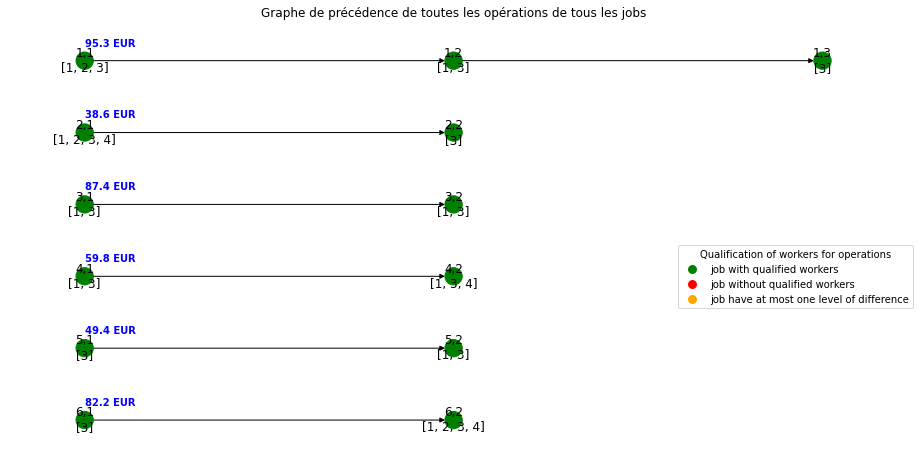

In [244]:
visualization_before_scheduling(simple_instance, not_qualified=True)

# ########## 5.2 Random Search \##########

In [245]:
# RANDOM SEARCH

encoding_dicos = Encoding_Dicos(simple_instance)

generator = ChromosomeGenerator(simple_instance, encoding_dicos, constraints_config)

decoder = Decoder(simple_instance, encoding_dicos, constraints_config)

weights = {
    "profit" : 100,
    "skills" : 50,
    "cognitive_load" : 1
}

evaluator = Evaluator(decoder, weights)


simple_random_search = RandomSearch(generator, evaluator)
MAX_ITER = 1000
all_viewed_list_RS, best_list_RS, i_find_best_list_RS = simple_random_search.run(MAX_ITER, verbose=True)

iter 0: New best fitness: 9867.539871656438
iter 11: New best fitness: 16974.697392976985
iter 45: New best fitness: 16995.064388272152
iter 90: New best fitness: 26507.90901270715


In [246]:
best = best_list_RS[-1]

In [247]:
print(best)

osc :
[0 5 0 2 2 0 5 3 4 4 1 3 1]
fwac:
[1 0 2 1 2 2 0 2 0 2 0 2 0]
swac:
[ 0  2 -1 -1  0  0  1  0  1 -1  2  3  2]
fitness: 26507.90901270715
objectives: (264.9098137718146, 1.0, 33.072364474309)



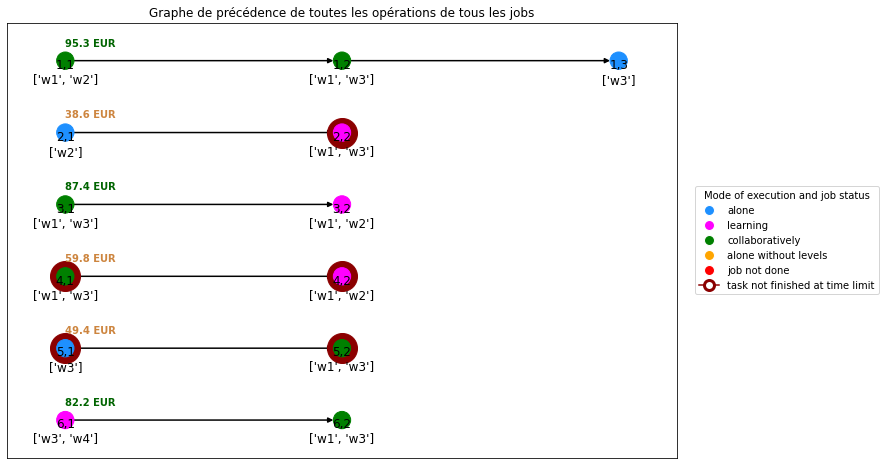

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


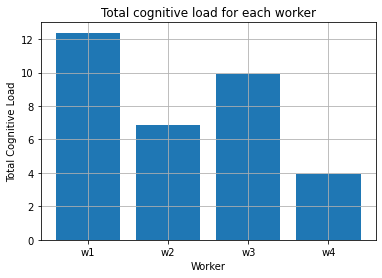

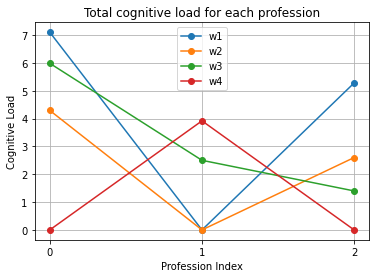

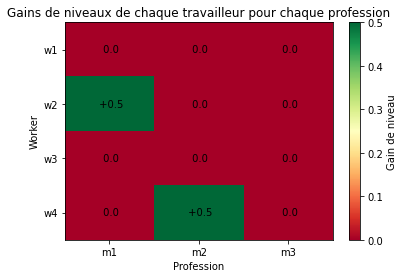

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(5,1)': '#FECB52', '(5,2)': '#1F77B4', '(6,1)': '#FF7F0E', '(6,2)': '#2CA02C'}


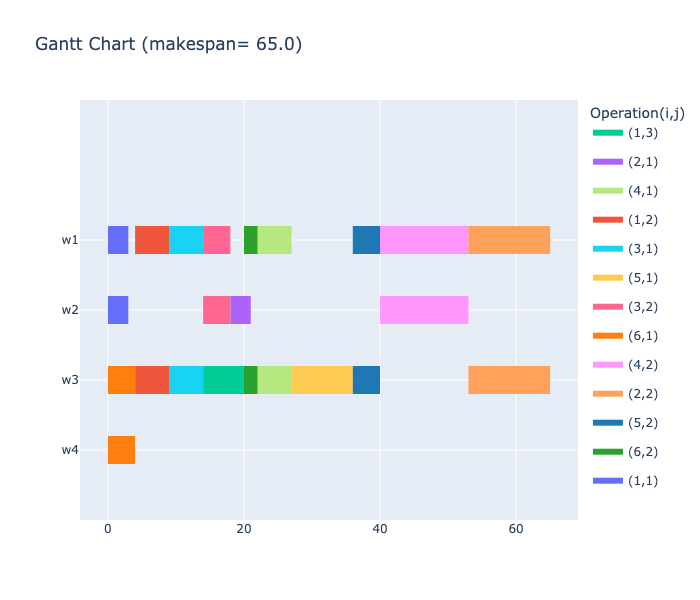

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,3.0,3.0,3.0,"(1,1)",J1,collaboratively,3.200709,3.0,0,before,before,23.0,2.0
1,w1,4.0,9.0,9.0,5.0,"(1,2)",J1,collaboratively,4.000000,3.0,0,before,before,0.0,0.0
2,w1,9.0,14.0,14.0,5.0,"(3,1)",J3,collaboratively,4.000000,3.0,0,before,before,0.0,0.0
3,w1,14.0,18.0,18.0,4.0,"(3,2)",J3,learning (tutor),4.000000,2.0,0,before,before,3.0,0.0
4,w1,20.0,22.0,22.0,2.0,"(6,2)",J6,collaboratively,3.200709,1.0,0,before,before,22.0,2.0
5,w1,22.0,27.0,27.0,5.0,"(4,1)",J4,collaboratively,4.000000,3.0,1.0,after,after,0.0,0.0
6,w1,36.0,40.0,40.0,4.0,"(5,2)",J5,collaboratively,4.000000,3.0,14.0,after,after,24.0,0.0
7,w1,40.0,53.0,53.0,13.0,"(4,2)",J4,learning (tutor),2.808406,2.0,27.0,after,after,8.0,1.0
8,w1,53.0,65.0,65.0,12.0,"(2,2)",J2,learning (apprentice),2.808406,3.0,39.0,after,after,12.0,1.0
9,w2,0.0,3.0,3.0,3.0,"(1,1)",J1,collaboratively,4.000000,3.0,0,before,before,23.0,2.0


In [248]:
s = decoder.decode_solution(best.osc, best.fwac, best.swac)

df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

# ########## 5.3 Local Search \##########

In [249]:
neighborhood_SWAP_OP = SwapOperationNeighborhood(n=10)
neighborhood_MOVE_OP = MoveOneOperationNeighborhood()
neighborhood_SWAP_FIXED = SwapFixedOperationsNeighborhood(k=10, n=10)
neighborhood_MOVE_SWAC = MoveSecondWorkerNeighborhood(generator)

softmax_selector = SoftmaxSelector()
best_selector = BestSelector()

In [250]:
selector = best_selector

local_search_swap_op = LocalSearch(
    generator, 
    evaluator,
    neighborhood_SWAP_OP,
    selector
)

local_search_move_op = LocalSearch(
    generator, 
    evaluator,
    neighborhood_MOVE_OP,
    selector
)

local_search_swap_fixed = LocalSearch(
    generator, 
    evaluator,
    neighborhood_SWAP_FIXED,
    selector
)

local_search_move_swac = LocalSearch(
    generator, 
    evaluator,
    neighborhood_MOVE_SWAC,
    selector
)

local_search_family = [local_search_swap_op, local_search_move_op, local_search_swap_fixed, local_search_move_swac]

In [251]:
solution_list = []
time_list = []
for i in range(len(local_search_family)):
    time_start = time.time()
    solution_list.append(local_search_family[i].run(MAX_ITER, verbose=True))
    time_list.append(time.time() - time_start)
    print("--")
    

Initial fitness: 0.0
iter 1: New best fitness: 8238.483472246657
iter 6: New best fitness: 8756.934833115858
iter 21: New best fitness: 14756.439135285551
iter 60: New best fitness: 16995.418305362517
iter 75: New best fitness: 21956.315437352212
--
Initial fitness: 0.0
iter 1: New best fitness: 8238.758648059313
iter 3: New best fitness: 16989.758168700064
iter 4: New best fitness: 20844.998120531134
--
Initial fitness: 0.0
iter 1: New best fitness: 3856.8727351742477
iter 2: New best fitness: 12607.276702137824
iter 5: New best fitness: 14726.226991311525
iter 20: New best fitness: 16988.16926480612
iter 23: New best fitness: 20845.041999980367
iter 24: New best fitness: 22963.99228915407
--
Initial fitness: 0.0
iter 97: New best fitness: 9530.474284768748
iter 122: New best fitness: 9549.380934551978
--


##### All solutions during iteration

In [252]:
y = [ [] for _ in range(len(solution_list)) ]

for i in range(len(solution_list)):
    for j in range(len(solution_list[i][0])):
        y[i].append(solution_list[i][0][j].fitness)
print(len(y), len(y[0]), len(y[1]), len(y[2]), len(y[3]))

4 1000 1000 1000 1000


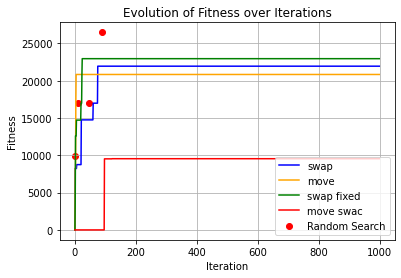

In [253]:
x = np.arange(len(solution_list[0][0]))

x_RS = i_find_best_list_RS
y_RS = [chromosome.fitness for chromosome in best_list_RS]


plt.plot(x, y[0], label='swap', color="blue")
plt.plot(x, y[1], label='move', color="orange")
plt.plot(x, y[2], label='swap fixed', color="green")
plt.plot(x, y[3], label='move swac', color="red")

plt.scatter(x_RS, y_RS, color='red', label='Random Search')


plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('Evolution of Fitness over Iterations')
plt.legend()
plt.grid()
plt.show()

##### Just Best changed solution during iteration

In [254]:
## Print best solutions found by each local search
ybest = [ [] for _ in range(len(solution_list)) ]

for i in range(len(solution_list)):
    for j in range(len(solution_list[i][1])):
        ybest[i].append(solution_list[i][1][j].fitness)
print(len(ybest), len(ybest[0]), len(ybest[1]), len(ybest[2]), len(ybest[3]))

4 6 4 7 3


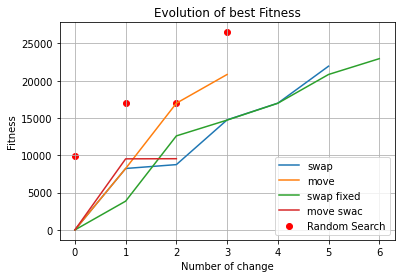

In [255]:
x = np.arange(len(solution_list[0][0]))

# x_RS = i_find_best_list_RS
y_RS = [chromosome.fitness for chromosome in best_list_RS]


plt.plot(np.arange(len(ybest[0])), ybest[0], label='swap')
plt.plot(np.arange(len(ybest[1])), ybest[1], label='move')
plt.plot(np.arange(len(ybest[2])), ybest[2], label='swap fixed')
plt.plot(np.arange(len(ybest[3])), ybest[3], label='move swac')

plt.scatter(np.arange(len(y_RS)), y_RS, color='red', label='Random Search')


plt.xlabel('Number of change')
plt.ylabel('Fitness')
plt.title('Evolution of best Fitness')
plt.legend()
plt.grid()
plt.show()

In [256]:
best_1, best_2, best_3, best_4 = solution_list[0][1][-1], solution_list[1][1][-1], solution_list[2][1][-1], solution_list[3][1][-1]
# print(best_1)
# print(best_2)
# print(best_3)
# print(best_4)

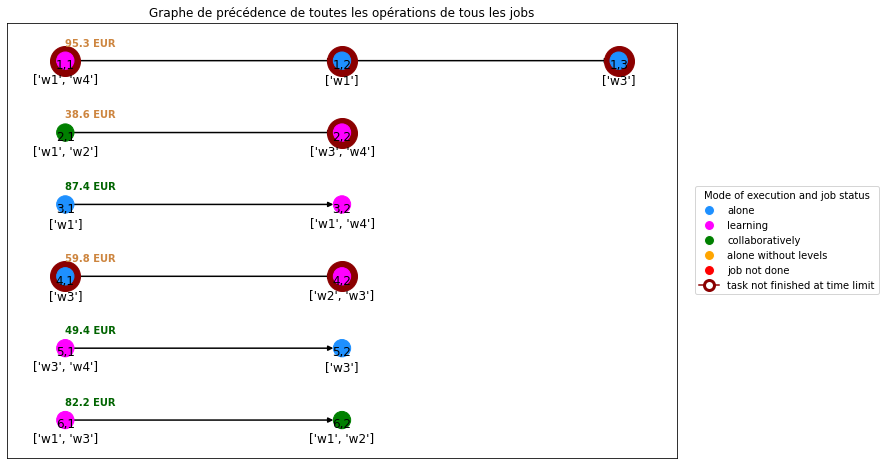

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


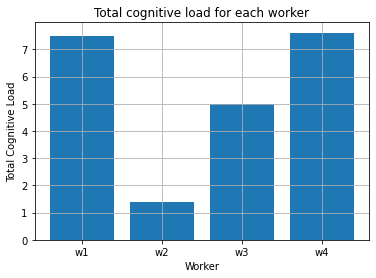

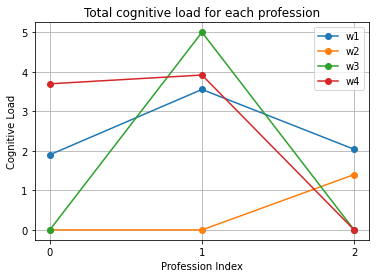

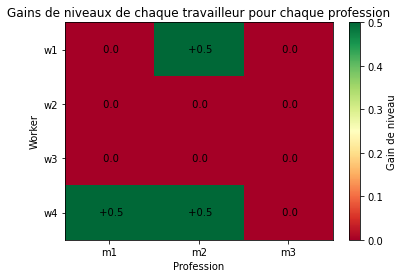

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(5,1)': '#FECB52', '(5,2)': '#1F77B4', '(6,1)': '#FF7F0E', '(6,2)': '#2CA02C'}


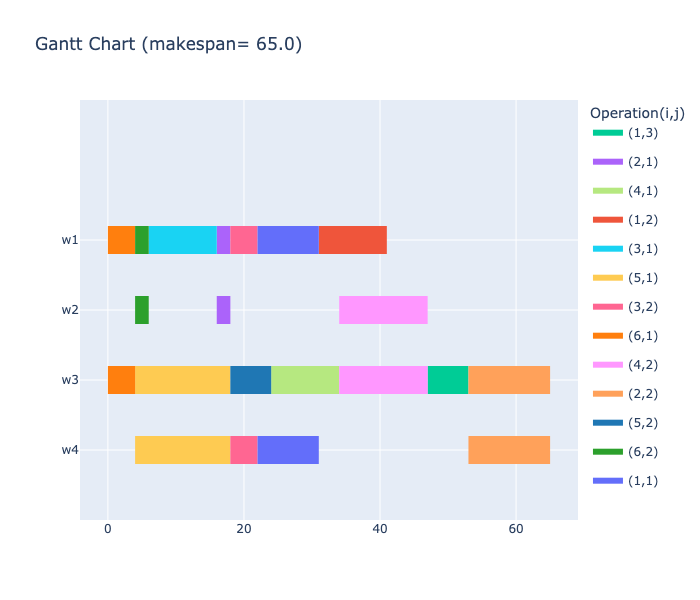

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,4.0,4.0,4.0,"(6,1)",J6,learning (apprentice),2.808406,3.0,0,before,before,10.0,1.0
1,w1,4.0,6.0,6.0,2.0,"(6,2)",J6,collaboratively,3.200709,1.0,0,before,before,22.0,2.0
2,w1,6.0,16.0,16.0,10.0,"(3,1)",J3,alone,4.000000,3.0,0,before,before,0.0,0.0
3,w1,16.0,18.0,18.0,2.0,"(2,1)",J2,collaboratively,3.200709,1.0,0,before,after,22.0,2.0
4,w1,18.0,22.0,22.0,4.0,"(3,2)",J3,learning (tutor),4.000000,2.0,0,before,before,3.0,0.0
5,w1,22.0,31.0,31.0,9.0,"(1,1)",J1,learning (tutor),3.200709,3.0,5.0,after,after,23.0,2.0
6,w1,31.0,41.0,41.0,10.0,"(1,2)",J1,alone,4.000000,3.0,15.0,after,after,0.0,0.0
7,w2,4.0,6.0,6.0,2.0,"(6,2)",J6,collaboratively,4.000000,1.0,0,before,before,22.0,2.0
8,w2,16.0,18.0,18.0,2.0,"(2,1)",J2,collaboratively,4.000000,1.0,0,before,after,22.0,2.0
9,w2,34.0,47.0,47.0,13.0,"(4,2)",J4,learning (apprentice),1.035003,2.0,21.0,after,after,8.0,1.0


In [257]:
s = decoder.decode_solution(best_1.osc, best_1.fwac, best_1.swac)

df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

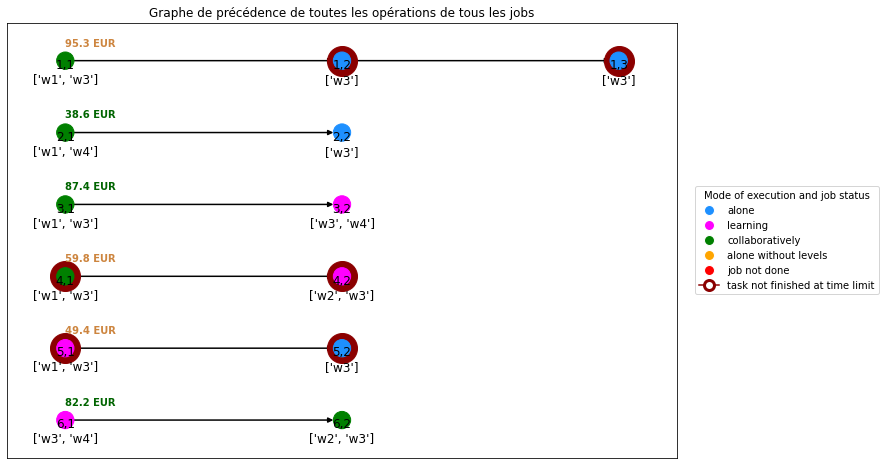

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


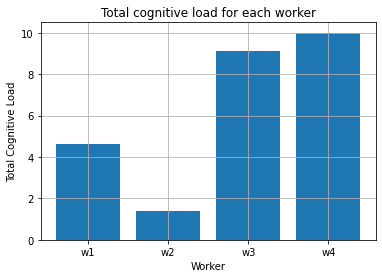

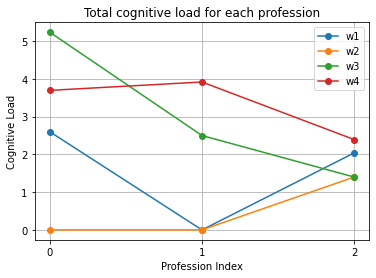

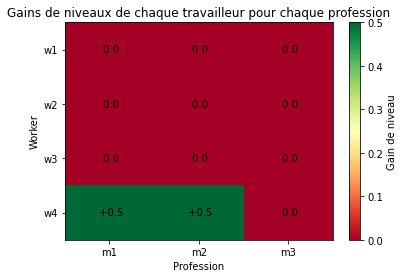

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(5,1)': '#FECB52', '(5,2)': '#1F77B4', '(6,1)': '#FF7F0E', '(6,2)': '#2CA02C'}


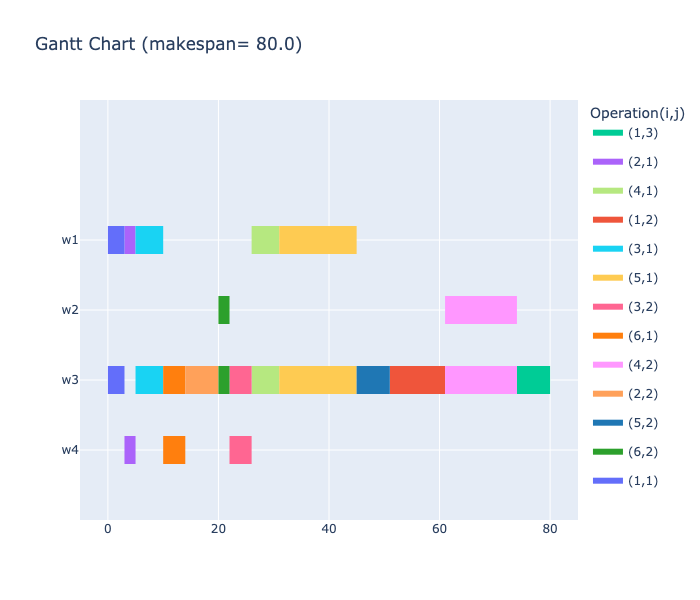

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,3.0,3.0,3.0,"(1,1)",J1,collaboratively,3.200709,3.0,0,before,after,23.0,2.0
1,w1,3.0,5.0,5.0,2.0,"(2,1)",J2,collaboratively,3.200709,1.0,0,before,before,22.0,2.0
2,w1,5.0,10.0,10.0,5.0,"(3,1)",J3,collaboratively,4.000000,3.0,0,before,before,0.0,0.0
3,w1,26.0,31.0,31.0,5.0,"(4,1)",J4,collaboratively,4.000000,3.0,5.0,after,after,0.0,0.0
4,w1,31.0,45.0,45.0,14.0,"(5,1)",J5,learning (apprentice),2.808406,3.0,19.0,after,after,11.0,1.0
5,w2,20.0,22.0,22.0,2.0,"(6,2)",J6,collaboratively,4.000000,1.0,0,before,before,22.0,2.0
6,w2,61.0,74.0,74.0,13.0,"(4,2)",J4,learning (apprentice),1.035003,2.0,48.0,after,after,8.0,1.0
7,w3,0.0,3.0,3.0,3.0,"(1,1)",J1,collaboratively,4.000000,3.0,0,before,after,23.0,2.0
8,w3,5.0,10.0,10.0,5.0,"(3,1)",J3,collaboratively,3.509792,3.0,0,before,before,0.0,0.0
9,w3,10.0,14.0,14.0,4.0,"(6,1)",J6,learning (tutor),4.000000,3.0,0,before,before,10.0,1.0


In [258]:
s = decoder.decode_solution(best_2.osc, best_2.fwac, best_2.swac)

df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

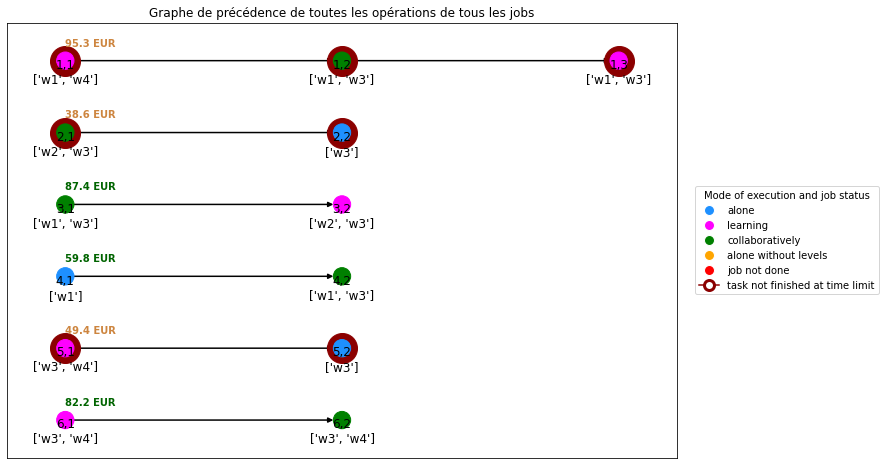

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


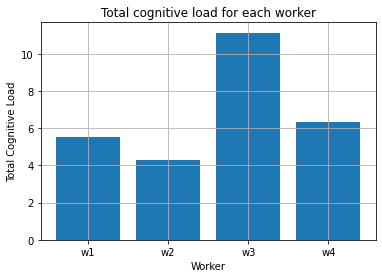

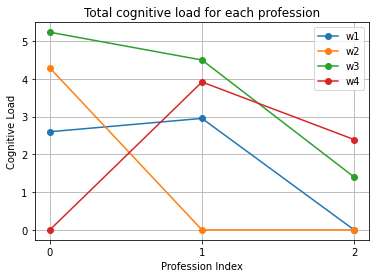

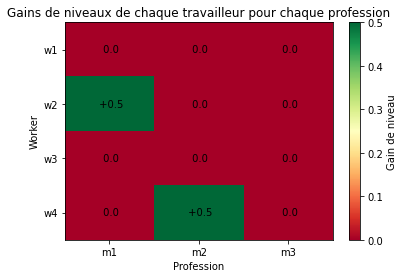

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(5,1)': '#FECB52', '(5,2)': '#1F77B4', '(6,1)': '#FF7F0E', '(6,2)': '#2CA02C'}


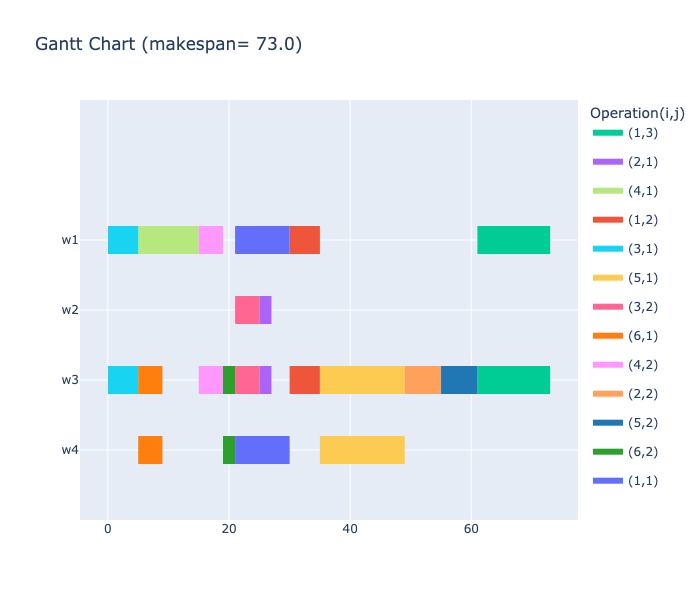

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,5.0,5.0,5.0,"(3,1)",J3,collaboratively,4.000000,3.0,0,before,before,0.0,0.0
1,w1,5.0,15.0,15.0,10.0,"(4,1)",J4,alone,4.000000,3.0,0,before,before,0.0,0.0
2,w1,15.0,19.0,19.0,4.0,"(4,2)",J4,collaboratively,2.808406,2.0,0,before,before,8.0,1.0
3,w1,21.0,30.0,30.0,9.0,"(1,1)",J1,learning (tutor),3.200709,3.0,4.0,after,after,23.0,2.0
4,w1,30.0,35.0,35.0,5.0,"(1,2)",J1,collaboratively,4.000000,3.0,9.0,after,after,0.0,0.0
5,w1,61.0,73.0,73.0,12.0,"(1,3)",J1,learning (apprentice),2.808406,3.0,47.0,after,after,12.0,1.0
6,w2,21.0,25.0,25.0,4.0,"(3,2)",J3,learning (apprentice),1.135460,2.0,0,before,before,3.0,0.0
7,w2,25.0,27.0,27.0,2.0,"(2,1)",J2,collaboratively,4.000000,1.0,1.0,after,after,22.0,2.0
8,w3,0.0,5.0,5.0,5.0,"(3,1)",J3,collaboratively,3.509792,3.0,0,before,before,0.0,0.0
9,w3,5.0,9.0,9.0,4.0,"(6,1)",J6,learning (tutor),4.000000,3.0,0,before,before,10.0,1.0


In [259]:
s = decoder.decode_solution(best_3.osc, best_3.fwac, best_3.swac)

df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

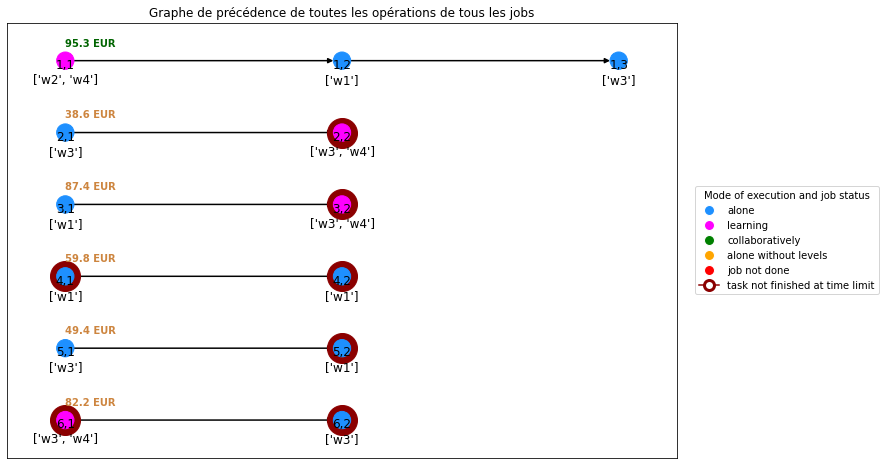

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


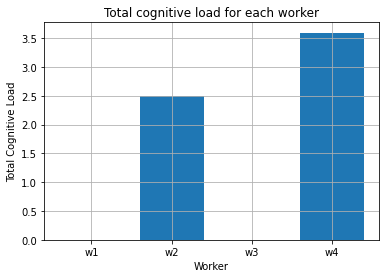

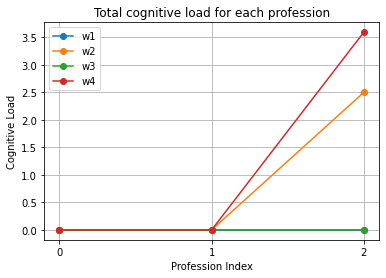

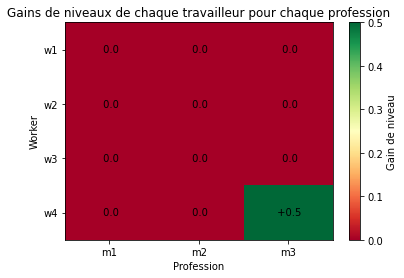

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(5,1)': '#FECB52', '(5,2)': '#1F77B4', '(6,1)': '#FF7F0E', '(6,2)': '#2CA02C'}


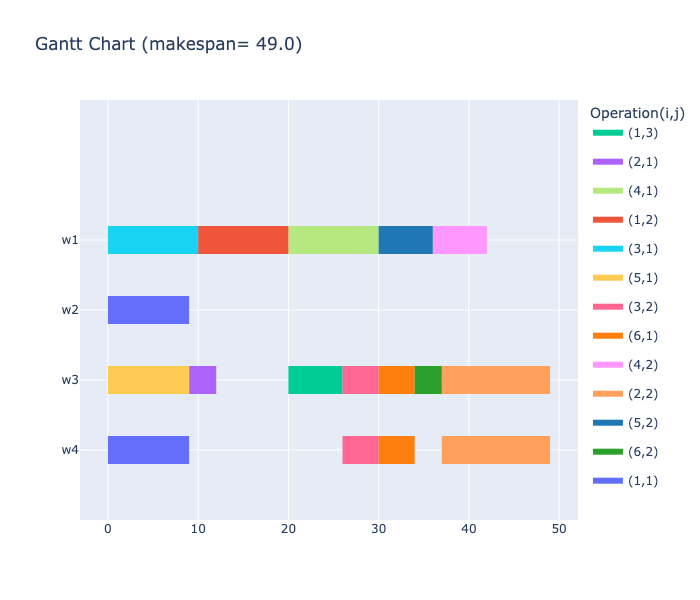

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,10.0,10.0,10.0,"(3,1)",J3,alone,4.000000,3.0,0,before,after,0.0,0.0
1,w1,10.0,20.0,20.0,10.0,"(1,2)",J1,alone,4.000000,3.0,0,before,before,0.0,0.0
2,w1,20.0,30.0,30.0,10.0,"(4,1)",J4,alone,4.000000,3.0,4.0,after,after,0.0,0.0
3,w1,30.0,36.0,36.0,6.0,"(5,2)",J5,alone,4.000000,3.0,10.0,after,after,24.0,0.0
4,w1,36.0,42.0,42.0,6.0,"(4,2)",J4,alone,2.808406,2.0,16.0,after,after,8.0,1.0
5,w2,0.0,9.0,9.0,9.0,"(1,1)",J1,learning (tutor),4.000000,3.0,0,before,before,23.0,2.0
6,w3,0.0,9.0,9.0,9.0,"(5,1)",J5,alone,4.000000,3.0,0,before,after,11.0,1.0
7,w3,9.0,12.0,12.0,3.0,"(2,1)",J2,alone,4.000000,1.0,0,before,after,22.0,2.0
8,w3,20.0,26.0,26.0,6.0,"(1,3)",J1,alone,4.000000,3.0,0,before,before,12.0,1.0
9,w3,26.0,30.0,30.0,4.0,"(3,2)",J3,learning (tutor),3.509792,2.0,4.0,after,after,3.0,0.0


In [260]:
s = decoder.decode_solution(best_4.osc, best_4.fwac, best_4.swac)

df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

# ########## 5.4 MILP Model \##########

In [ ]:
constraints_config["init_affectation_variables"] = False
model = Model(simple_instance)
s_list = []
runtime_list = []
for _ in range(10):
    s_list.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constr

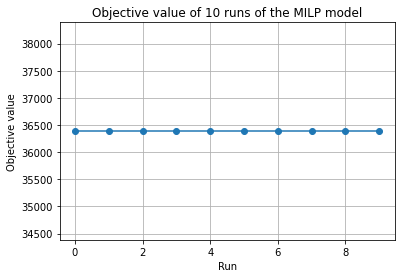

In [310]:
y = [s_list[i].objective_values[0] for i in range(len(s_list))]
plt.plot(y, marker='o')
plt.xlabel('Run')
plt.ylabel('Objective value')
plt.title('Objective value of 10 runs of the MILP model')
plt.grid()
plt.show()

- Runtime : 

In [311]:
runtime_list = np.array(runtime_list)
print(runtime_list)
print("mean runtime :", np.mean(runtime_list))
print("std runtime :", np.std(runtime_list))

[5.18733287 4.94819689 4.32938099 4.43343806 4.352036   4.89911604
 4.8843329  4.98713613 4.94827795 5.04335499]
mean runtime : 4.801260280609131
std runtime : 0.29354025202922546


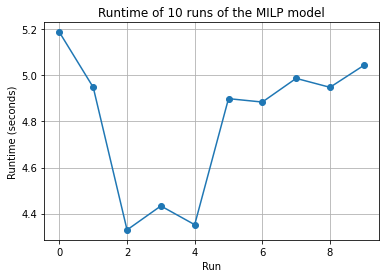

In [312]:
plt.plot(runtime_list, marker='o')
plt.xlabel('Run')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime of 10 runs of the MILP model')
plt.grid()
plt.show()

In [313]:
s = s_list[0]

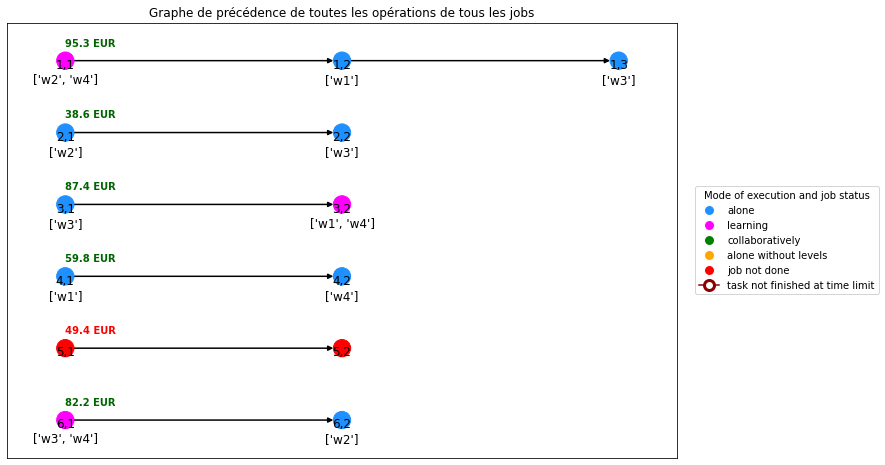

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
All conditions are satisfied for the Gantt chart.


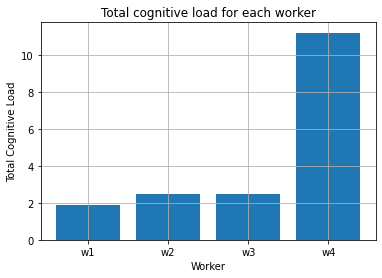

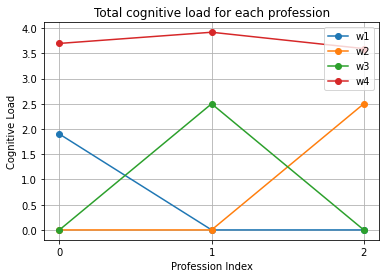

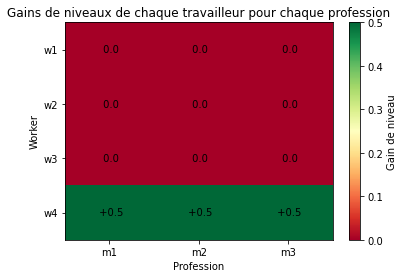

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(1,3)': '#00CC96', '(2,1)': '#AB63FA', '(2,2)': '#FFA15A', '(3,1)': '#19D3F3', '(3,2)': '#FF6692', '(4,1)': '#B6E880', '(4,2)': '#FF97FF', '(6,1)': '#FECB52', '(6,2)': '#1F77B4'}


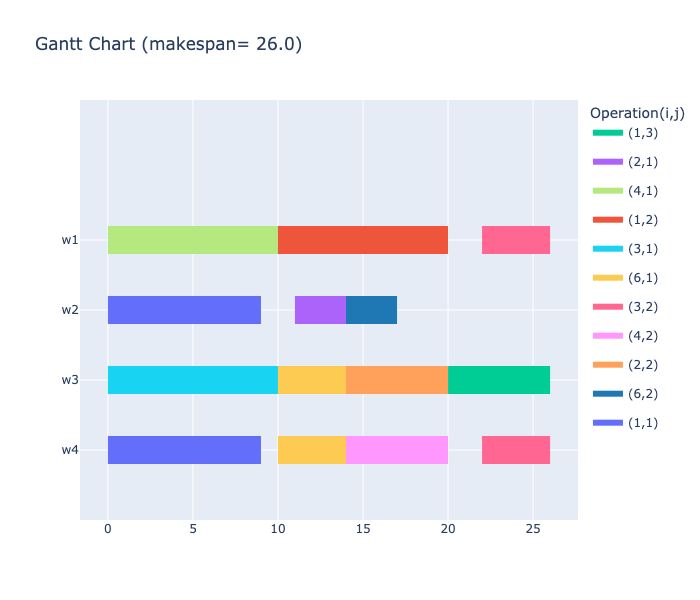

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.0,10.0,10.0,10.0,"(4,1)",J4,alone,4.000000,3.0,0,before,before,0.0,0.0
1,w1,10.0,20.0,20.0,10.0,"(1,2)",J1,alone,4.000000,3.0,0,before,before,0.0,0.0
2,w1,22.0,26.0,26.0,4.0,"(3,2)",J3,learning (tutor),4.000000,2.0,0,before,before,3.0,0.0
3,w2,0.0,9.0,9.0,9.0,"(1,1)",J1,learning (tutor),4.000000,3.0,0,before,before,23.0,2.0
4,w2,11.0,14.0,14.0,3.0,"(2,1)",J2,alone,4.000000,1.0,0,before,before,22.0,2.0
5,w2,14.0,17.0,17.0,3.0,"(6,2)",J6,alone,4.000000,1.0,0,before,before,22.0,2.0
6,w3,0.0,10.0,10.0,10.0,"(3,1)",J3,alone,3.509792,3.0,0,before,before,0.0,0.0
7,w3,10.0,14.0,14.0,4.0,"(6,1)",J6,learning (tutor),4.000000,3.0,0,before,before,10.0,1.0
8,w3,14.0,20.0,20.0,6.0,"(2,2)",J2,alone,4.000000,3.0,0,before,before,12.0,1.0
9,w3,20.0,26.0,26.0,6.0,"(1,3)",J1,alone,4.000000,3.0,0,before,before,12.0,1.0


In [314]:
df = scheduling_to_df(s, simple_instance)
visualization_after_scheduling(simple_instance, s, df)
check_df(df)


bars_cognitive_load_total(s, simple_instance)
plot_cognitive_load_total(s, simple_instance)
resume_levels_workers(s, simple_instance)
gantt_chart(df, color=0, render="notebook")
df

In [315]:
print(s.objective_values)

{0: 36388.32345071793}


In [316]:
np.sum(s.job_done*simple_instance.resale_price_jobs), np.sum(s.l)-np.sum(simple_instance.levels_workers), np.sum(s.cognitive_load_total)

(363.3143041217224, 1.5, 18.106961454308834)

In [317]:
print(best_1)
print(best_2)
print(best_3)
print(best_4)

osc :
[5 4 5 2 1 2 0 4 3 0 3 0 1]
fwac:
[0 0 2 1 2 0 0 2 2 2 2 2 1]
swac:
[ 3 -1 -1  0  3 -1  3 -1  1  3 -1  0  0]
fitness: 21956.315437352212
objectives: (219.0282175718474, 1.5, 21.50631983252725)

osc :
[0 1 2 5 1 5 2 3 4 4 0 3 0]
fwac:
[2 2 2 3 2 2 2 2 2 2 2 2 2]
swac:
[ 0 -1 -1  0 -1  0  3  0  1  0 -1  3  1]
fitness: 20844.998120531134
objectives: (208.20179827586958, 1.0, 25.18170705582401)

osc :
[2 3 5 3 5 2 0 1 0 4 1 4 0]
fwac:
[0 2 2 2 2 2 2 0 0 2 2 2 3]
swac:
[ 3  0  0  1 -1  0  1 -1  2  3 -1  3  2]
fitness: 22963.99228915407
objectives: (229.4128339222924, 1.0, 27.291103075170998)

osc :
[2 0 4 0 1 0 2 3 5 5 4 3 1]
fwac:
[1 0 2 2 2 0 2 0 0 2 0 2 2]
swac:
[ 3 -1 -1 -1  3 -1  3 -1 -1 -1 -1  3 -1]
fitness: 9549.380934551978
objectives: (95.30474284768749, 0.5, 6.093350216770098)



---

Pour le début de la résolution, fixé la variable d'affectation x et d aux valeurs trouvées par solutions précédentes

In [318]:
s_init_RS = decoder.decode_solution(best.osc, best.fwac, best.swac)

s_init_swap = decoder.decode_solution(best_1.osc, best_1.fwac, best_1.swac)
s_init_move = decoder.decode_solution(best_2.osc, best_2.fwac, best_2.swac)
s_init_swap_fixed = decoder.decode_solution(best_3.osc, best_3.fwac, best_3.swac)
s_init_move_swac = decoder.decode_solution(best_4.osc, best_4.fwac, best_4.swac)

s_init_milp = s_list[0]

- Random Search :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_RS.x, s_init_RS.d]

s_milp_init_RS = []
runtime_MILP_init_RS_list = []
for i in range(10):
    s_milp_init_RS.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_RS_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constr

In [333]:
y_MILP_init_RS = [s_milp_init_RS[i].objective_values[0] for i in range(len(s_milp_init_RS))]

In [323]:
print(runtime_MILP_init_RS_list)

[4.657605886459351, 4.796162128448486, 4.434025049209595, 4.698976993560791, 5.4809889793396, 4.377578973770142, 4.346382141113281, 4.243310213088989, 4.8457159996032715, 4.676996946334839]


- swap :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_swap.x, s_init_swap.d]

s_milp_init_swap = []
runtime_MILP_init_swap_list = []
for i in range(10):
    s_milp_init_swap.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_swap_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ==========

In [335]:
y_MILP_init_swap = [s_milp_init_swap[i].objective_values[0] for i in range(len(s_milp_init_swap))]

- move :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_move.x, s_init_move.d]

s_milp_init_move = []
runtime_MILP_init_move_list = []
for i in range(10):
    s_milp_init_move.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_move_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ==========

In [339]:
y_MILP_init_move = [s_milp_init_move[i].objective_values[0] for i in range(len(s_milp_init_move))]

- swap_fixed :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_swap_fixed.x, s_init_swap_fixed.d]

s_milp_init_swap_fixed = []
runtime_MILP_init_swap_fixed_list = []
for i in range(10):
    s_milp_init_swap_fixed.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_swap_fixed_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ==========

In [343]:
y_MILP_init_swap_fixed = [s_milp_init_swap_fixed[i].objective_values[0] for i in range(len(s_milp_init_swap_fixed))]

- move_swac :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_move_swac.x, s_init_move_swac.d]

s_milp_init_move_swac = []
runtime_MILP_init_move_swac_list = []
for i in range(10):
    s_milp_init_move_swac.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_move_swac_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 10
et la -> 26.0

 ==========

In [346]:
y_MILP_init_move_swac = [s_milp_init_move_swac[i].objective_values[0] for i in range(len(s_milp_init_move_swac))]

- milp :

In [ ]:
constraints_config["init_affectation_variables"] = [s_init_milp.x, s_init_milp.d]

s_milp_init_milp = []
runtime_MILP_init_milp_list = []
for i in range(10):
    s_milp_init_milp.append(model.solve(objective="three", weight=[100, 50, 1], constraints_config=constraints_config, verbose=False))
    runtime_MILP_init_milp_list.append(model.m.Runtime)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 1
et la -> 26.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  26.0
constrained makespan activated with limit = 26.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 26.0
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 36388.32345071793
nObjectives 1
nSolutions 1
et la -> 26.0

 ========== S

In [351]:
y_MILP_init_milp = [s_milp_init_milp[i].objective_values[0] for i in range(len(s_milp_init_milp))]

- Runtime :

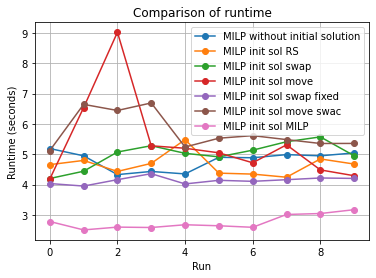

In [353]:
plt.plot(runtime_list, marker='o', label="MILP without initial solution")
plt.plot(runtime_MILP_init_RS_list, marker='o', label="MILP init sol RS")
plt.plot(runtime_MILP_init_swap_list, marker='o', label="MILP init sol swap")
plt.plot(runtime_MILP_init_move_list, marker='o', label="MILP init sol move")
plt.plot(runtime_MILP_init_swap_fixed_list, marker='o', label="MILP init sol swap fixed")
plt.plot(runtime_MILP_init_move_swac_list, marker='o', label="MILP init sol move swac")
plt.plot(runtime_MILP_init_milp_list, marker='o', label="MILP init sol MILP")

plt.xlabel('Run')
plt.ylabel('Runtime (seconds)')
plt.legend()
plt.grid()
plt.title("Comparison of runtime")
plt.show()

- Objective value :

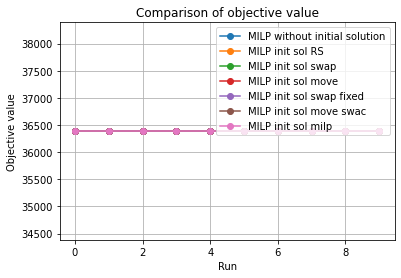

In [352]:
plt.plot(y, marker='o', label="MILP without initial solution")
plt.plot(y_MILP_init_RS, marker='o', label="MILP init sol RS")
plt.plot(y_MILP_init_swap, marker='o', label="MILP init sol swap")
plt.plot(y_MILP_init_move, marker='o', label="MILP init sol move")
plt.plot(y_MILP_init_swap_fixed, marker='o', label="MILP init sol swap fixed")
plt.plot(y_MILP_init_move_swac, marker='o', label="MILP init sol move swac")
plt.plot(y_MILP_init_milp, marker='o', label="MILP init sol milp")
plt.xlabel('Run')
plt.ylabel('Objective value')
plt.legend()
plt.grid()
plt.title("Comparison of objective value")
plt.show()

# #####Lancement sur plusieurs seeds des méthodes de Random Search et de Recherche locale\#####

In [ ]:
NB_SEEDS = 5
constraints_config["init_affectation_variables"] = False

In [359]:
# Récuperer temps de resolution de chaque algorithme pour chaque seed  (À faire)

random_search_list_seeds = [[] for _ in range(NB_SEEDS)]
local_search_swap_list_seeds = [[] for _ in range(NB_SEEDS)]
local_search_move_list_seeds = [[] for _ in range(NB_SEEDS)]
local_search_swap_fixed_list_seeds = [[] for _ in range(NB_SEEDS)]
local_search_move_swac_list_seeds = [[] for _ in range(NB_SEEDS)]



# for seed in range(NB_SEEDS):
#     print(f"seed : {seed}")
#     random_search_list_seeds[seed].append(simple_random_search.run(MAX_ITER, verbose=False))


for seed in range(NB_SEEDS):
    print(f"seed : {seed}")
    local_search_swap_list_seeds[seed].append(local_search_family[0].run(MAX_ITER, verbose=False))


    

seed : 0
seed : 1
seed : 2
seed : 3
seed : 4


In [ ]:
len(local_search_swap_list_seeds[0][0][0])

4

In [ ]:
y_local_search_swap_list_seeds = [ [] for _ in range(len(NB_SEEDS)) ]

for i in range(len(NB_SEEDS)):
    for j in range(len(solution_list[i][0])):
        y[i].append(solution_list[i][0][j].fitness)
print(len(y), len(y[0]), len(y[1]), len(y[2]), len(y[3]))

1000